# EDA - Base de películas IMDB (TP Grupal)

Análisis exploratorio de `movie.sqlite`: características generales del dataset,
tipos de variables, estadística descriptiva y relaciones. Sirve de base para las
diapositivas del grupo.

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Carga desde SQLite e inspección

La base tiene 3 tablas relacionadas por `Movie_id`.

In [2]:
con = sqlite3.connect("movie.sqlite")
tablas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)
print(tablas["name"].tolist())

imdb = pd.read_sql("SELECT * FROM IMDB", con)
earning = pd.read_sql("SELECT * FROM earning", con)
genre = pd.read_sql("SELECT * FROM genre", con)
con.close()

print("IMDB:", imdb.shape, "| earning:", earning.shape, "| genre:", genre.shape)

['IMDB', 'earning', 'genre']
IMDB: (117, 52) | earning: (117, 3) | genre: (351, 2)


In [3]:
imdb.iloc[:, :8].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Movie_id    117 non-null    object 
 1   Title       117 non-null    object 
 2   Rating      117 non-null    float64
 3   TotalVotes  117 non-null    int64  
 4   MetaCritic  117 non-null    object 
 5   Budget      117 non-null    object 
 6   Runtime     117 non-null    object 
 7   CVotes10    117 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 7.4+ KB


### Diccionario de datos

Qué representa cada campo de las 3 tablas. La mayoría de las columnas de `IMDB` son
el voto desagregado por demografía, con dos prefijos: **`CVotes*`** = *cantidad* de
votos de ese grupo y **`Votes*`** = *rating promedio* que dio ese grupo.

In [4]:
# Diccionario de datos: qué representa cada campo
# Convención: CVotes* = CANTIDAD de votos de un grupo | Votes* = RATING PROMEDIO de ese grupo
desc = {
    # --- IMDB: contenido ---
    "Movie_id": "Identificador único de la película (clave para unir las 3 tablas)",
    "Title": "Título de la película (incluye el año)",
    "Rating": "Calificación promedio en IMDB (escala 0-10)",
    "TotalVotes": "Cantidad total de votos recibidos en IMDB",
    "MetaCritic": "Puntaje de Metacritic (escala 0-100)",
    "Budget": "Presupuesto de producción (USD)",
    "Runtime": "Duración de la película (minutos)",
    # --- IMDB: cantidad de votos por puntaje otorgado ---
    **{f"CVotes{n:02d}": f"Cantidad de votos con puntaje {n}" for n in range(10, 0, -1)},
    # --- IMDB: cantidad de votos por género ---
    "CVotesMale": "Cantidad de votos de usuarios varones",
    "CVotesFemale": "Cantidad de votos de usuarias mujeres",
    # --- IMDB: cantidad de votos por edad (y género) ---
    "CVotesU18": "Cantidad de votos de menores de 18 años",
    "CVotesU18M": "Cantidad de votos de varones menores de 18 años",
    "CVotesU18F": "Cantidad de votos de mujeres menores de 18 años",
    "CVotes1829": "Cantidad de votos de usuarios de 18 a 29 años",
    "CVotes1829M": "Cantidad de votos de varones de 18 a 29 años",
    "CVotes1829F": "Cantidad de votos de mujeres de 18 a 29 años",
    "CVotes3044": "Cantidad de votos de usuarios de 30 a 44 años",
    "CVotes3044M": "Cantidad de votos de varones de 30 a 44 años",
    "CVotes3044F": "Cantidad de votos de mujeres de 30 a 44 años",
    "CVotes45A": "Cantidad de votos de usuarios de 45 años o más",
    "CVotes45AM": "Cantidad de votos de varones de 45 años o más",
    "CVotes45AF": "Cantidad de votos de mujeres de 45 años o más",
    # --- IMDB: cantidad de votos por origen / segmento ---
    "CVotes1000": "Cantidad de votos de los Top 1000 votantes de IMDB",
    "CVotesUS": "Cantidad de votos de usuarios de Estados Unidos",
    "CVotesnUS": "Cantidad de votos de usuarios fuera de Estados Unidos",
    # --- IMDB: rating promedio por grupo ---
    "VotesM": "Rating promedio otorgado por varones",
    "VotesF": "Rating promedio otorgado por mujeres",
    "VotesU18": "Rating promedio otorgado por menores de 18 años",
    "VotesU18M": "Rating promedio otorgado por varones menores de 18 años",
    "VotesU18F": "Rating promedio otorgado por mujeres menores de 18 años",
    "Votes1829": "Rating promedio otorgado por usuarios de 18 a 29 años",
    "Votes1829M": "Rating promedio otorgado por varones de 18 a 29 años",
    "Votes1829F": "Rating promedio otorgado por mujeres de 18 a 29 años",
    "Votes3044": "Rating promedio otorgado por usuarios de 30 a 44 años",
    "Votes3044M": "Rating promedio otorgado por varones de 30 a 44 años",
    "Votes3044F": "Rating promedio otorgado por mujeres de 30 a 44 años",
    "Votes45A": "Rating promedio otorgado por usuarios de 45 años o más",
    "Votes45AM": "Rating promedio otorgado por varones de 45 años o más",
    "Votes45AF": "Rating promedio otorgado por mujeres de 45 años o más",
    "VotesIMDB": "Rating promedio general reportado por IMDB",
    "Votes1000": "Rating promedio otorgado por los Top 1000 votantes",
    "VotesUS": "Rating promedio otorgado por usuarios de Estados Unidos",
    "VotesnUS": "Rating promedio otorgado por usuarios fuera de Estados Unidos",
    # --- earning ---
    "Domestic": "Recaudación en EE.UU. y Canadá (USD)",
    "Worldwide": "Recaudación mundial total (USD)",
    # --- genre ---
    "genre": "Género de la película (una fila por género; relación 1-a-muchos)",
}

filas = []
for tabla, cols in [("IMDB", imdb.columns), ("earning", earning.columns), ("genre", genre.columns)]:
    for c in cols:
        filas.append({"tabla": tabla, "campo": c, "descripción": desc.get(c, "")})

diccionario = pd.DataFrame(filas)
pd.set_option("display.max_rows", None, "display.max_colwidth", None)
diccionario

,tabla,campo,descripción
0,IMDB,Movie_id,Identificador único de la película (clave para unir las 3 tablas)
1,IMDB,Title,Título de la película (incluye el año)
2,IMDB,Rating,Calificación promedio en IMDB (escala 0-10)
3,IMDB,TotalVotes,Cantidad total de votos recibidos en IMDB
4,IMDB,MetaCritic,Puntaje de Metacritic (escala 0-100)
5,IMDB,Budget,Presupuesto de producción (USD)
6,IMDB,Runtime,Duración de la película (minutos)
7,IMDB,CVotes10,Cantidad de votos con puntaje 10
8,IMDB,CVotes09,Cantidad de votos con puntaje 9
9,IMDB,CVotes08,Cantidad de votos con puntaje 8


## 2. Tipos de variables y limpieza

Varias columnas numéricas vienen guardadas como texto (con vacíos y unidades),
así que hay que convertirlas.

In [5]:
# Runtime viene como '134 min'; MetaCritic y Budget como texto con vacíos
imdb["Runtime"] = pd.to_numeric(
    imdb["Runtime"].astype(str).str.replace(" min", "", regex=False), errors="coerce")
imdb["MetaCritic"] = pd.to_numeric(imdb["MetaCritic"], errors="coerce")
imdb["Budget"] = pd.to_numeric(imdb["Budget"], errors="coerce")

# Unimos películas con su recaudación
df = imdb.merge(earning, on="Movie_id", how="left")
print("Dataset unido:", df.shape)

# Nulos que aparecen tras la conversión
faltantes = df[["MetaCritic", "Budget", "Runtime", "Worldwide"]].isna().sum()
faltantes

Dataset unido: (117, 54)


MetaCritic     7
Budget         3
Runtime       21
Worldwide      0
dtype: int64

In [6]:
# Género tiene una relación 1-a-muchos y algunas filas vacías
print("Filas en genre:", len(genre), "| géneros únicos:", genre["genre"].nunique())
print("Filas con género vacío:", (genre["genre"] == "").sum())

Filas en genre: 351 | géneros únicos: 21
Filas con género vacío: 41


## 3. Estadística descriptiva

In [7]:
num_foco = ["Rating", "Runtime", "MetaCritic", "Budget", "Worldwide", "TotalVotes"]
df[num_foco].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
Rating,117.0,7.9,0.2,7.5,7.7,7.8,8.0,8.800000e+00
Runtime,96.0,126.6,19.6,91.0,112.8,125.5,138.2,1.800000e+02
MetaCritic,110.0,77.8,8.9,62.0,72.0,77.5,82.8,1.000000e+02
Budget,114.0,74596491.2,75078810.4,1000000.0,15000000.0,40000000.0,148750000.0,2.600000e+08
Worldwide,117.0,340378011.8,371945532.5,22321.0,68263166.0,201634991.0,494878759.0,2.068224e+09
TotalVotes,117.0,375579.1,262705.6,26016.0,222343.0,337571.0,512526.0,1.609713e+06


In [8]:
# Forma de la distribución del rating
pd.Series({
    "media": df["Rating"].mean(),
    "mediana": df["Rating"].median(),
    "moda": df["Rating"].mode().iloc[0],
    "desv_std": df["Rating"].std(),
    "skew": df["Rating"].skew(),
    "curtosis": df["Rating"].kurt(),
}).round(2)

media       7.87
mediana     7.80
moda        7.80
desv_std    0.24
skew        1.00
curtosis    1.59
dtype: float64

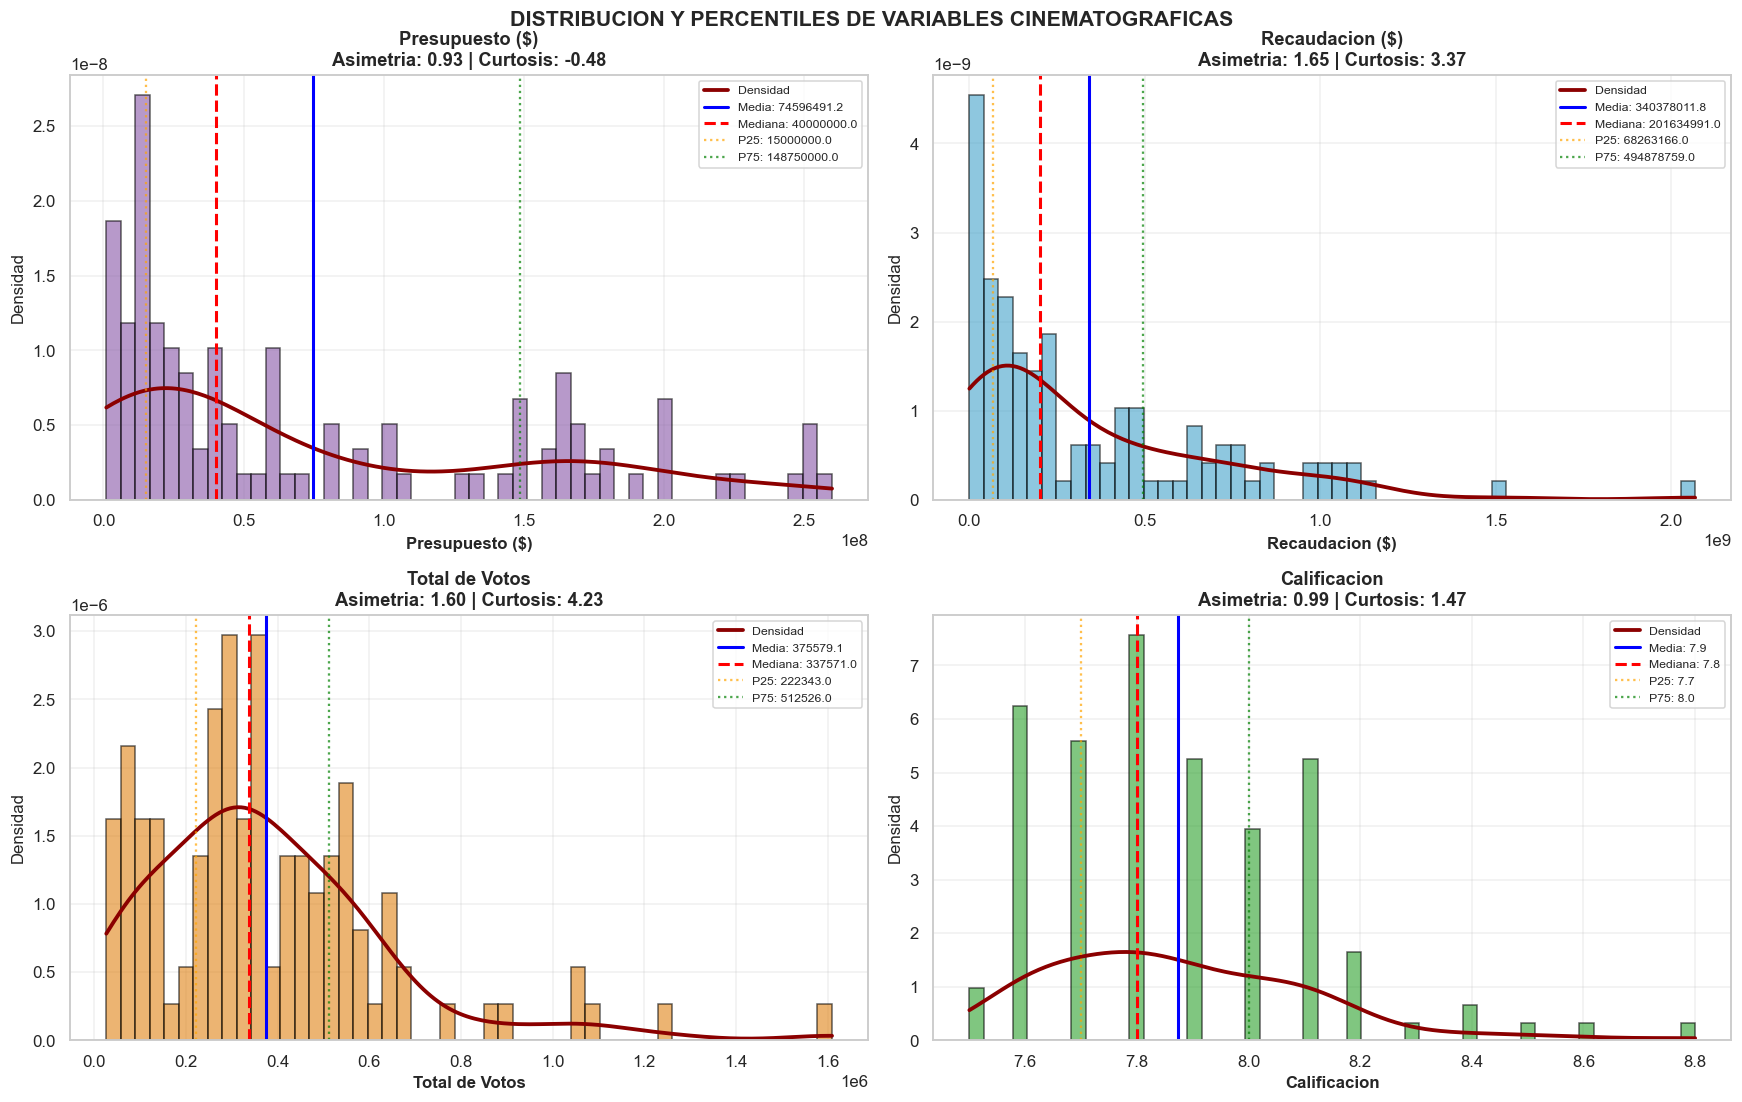


TABLA DE PERCENTILES (25%, 50%, 75%)
           Budget    Worldwide  TotalVotes  Rating
0.25   15000000.0   68263166.0    222343.0     7.7
0.50   40000000.0  201634991.0    337571.0     7.8
0.75  148750000.0  494878759.0    512526.0     8.0


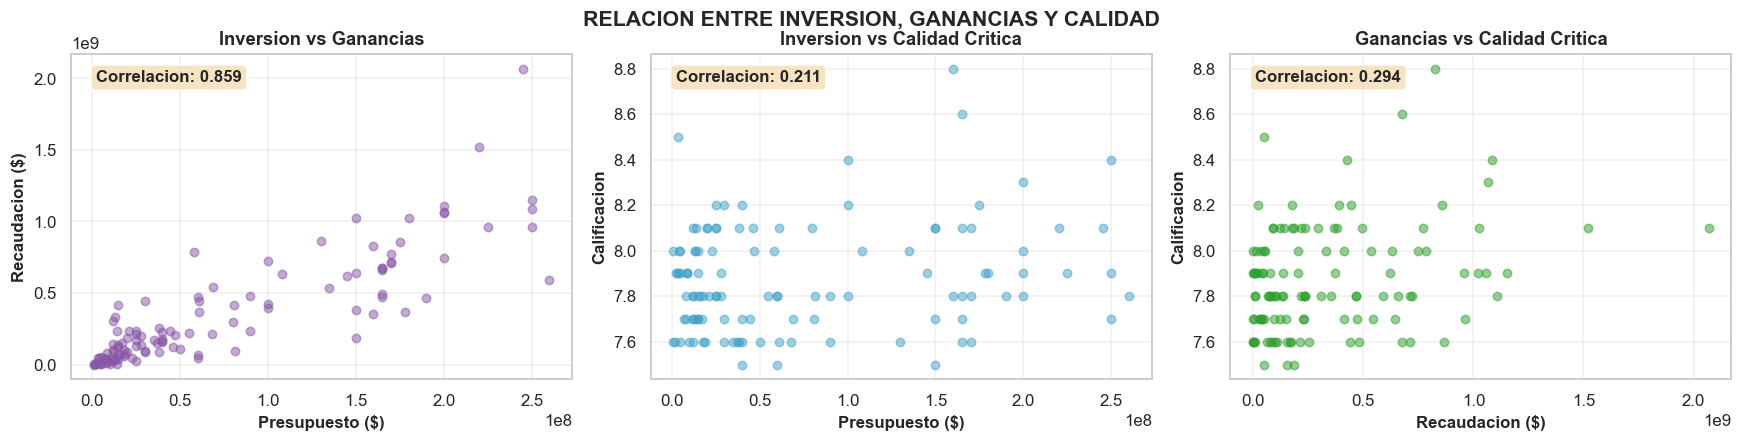


ESTADISTICOS DE FORMA DE LA DISTRIBUCION
Variable             Asimetria       Curtosis        Interpretacion                          
Budget               0.928           -0.476          Cola larga derecha (concentracion extrema)
Worldwide            1.648           3.365           Cola larga derecha (concentracion extrema)
TotalVotes           1.599           4.229           Cola larga derecha (concentracion extrema)
Rating               0.991           1.473           Cola larga derecha (concentracion extrema)


In [9]:
from scipy.stats import skew, kurtosis, pearsonr
import numpy as np
import seaborn as sns

# ==========================================
# 1. GRAFICAS DE DISTRIBUCION (4 variables)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

variables = ["Budget", "Worldwide", "TotalVotes", "Rating"]
colors = ["#8856a7", "#43a2ca", "#e08214", "#2ca02c"]
labels = ["Presupuesto ($)", "Recaudacion ($)", "Total de Votos", "Calificacion"]

for idx, (var, color, label) in enumerate(zip(variables, colors, labels)):
    # Histograma
    axes[idx].hist(df[var], bins=50, color=color, alpha=0.6, edgecolor="black", density=True)

    # Curva de densidad (KDE)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(df[var].dropna())
    x_range = np.linspace(df[var].min(), df[var].max(), 200)
    axes[idx].plot(x_range, kde(x_range), color="darkred", linewidth=2.5, label="Densidad")

    # Lineas de media y mediana
    media = df[var].mean()
    mediana = df[var].median()
    axes[idx].axvline(media, color="blue", linestyle="-", linewidth=2, label=f"Media: {media:.1f}")
    axes[idx].axvline(mediana, color="red", linestyle="--", linewidth=2, label=f"Mediana: {mediana:.1f}")

    # Percentiles 25, 50, 75
    p25, p50, p75 = df[var].quantile([0.25, 0.50, 0.75])
    axes[idx].axvline(p25, color="orange", linestyle=":", linewidth=1.5, alpha=0.7, label=f"P25: {p25:.1f}")
    axes[idx].axvline(p75, color="green", linestyle=":", linewidth=1.5, alpha=0.7, label=f"P75: {p75:.1f}")

    # Estadisticos de forma
    asimetria = skew(df[var].dropna())
    curt = kurtosis(df[var].dropna())

    axes[idx].set_xlabel(label, fontsize=11, fontweight="bold")
    axes[idx].set_ylabel("Densidad", fontsize=11)
    axes[idx].set_title(f"{label}\nAsimetria: {asimetria:.2f} | Curtosis: {curt:.2f}",
                        fontsize=12, fontweight="bold")
    axes[idx].legend(fontsize=8, loc="upper right")
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("DISTRIBUCION Y PERCENTILES DE VARIABLES CINEMATOGRAFICAS",
             fontsize=14, fontweight="bold", y=1.00)
plt.show()

# ==========================================
# 2. TABLA DE PERCENTILES
# ==========================================
print("\n" + "="*90)
print("TABLA DE PERCENTILES (25%, 50%, 75%)")
print("="*90)
percentiles = [0.25, 0.50, 0.75]
print(df[["Budget", "Worldwide", "TotalVotes", "Rating"]].quantile(percentiles).to_string())
print("="*90)

# ==========================================
# 3. MATRIZ DE CORRELACION
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Budget vs Worldwide
ax1 = axes[0]
ax1.scatter(df["Budget"], df["Worldwide"], alpha=0.5, color="#8856a7", s=30)
ax1.set_xlabel("Presupuesto ($)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Recaudacion ($)", fontsize=11, fontweight="bold")
ax1.set_title("Inversion vs Ganancias", fontsize=12, fontweight="bold")
corr_bw = df["Budget"].corr(df["Worldwide"])
ax1.text(0.05, 0.95, f"Correlacion: {corr_bw:.3f}",
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontweight="bold")
ax1.grid(alpha=0.3)

# Budget vs Rating
ax2 = axes[1]
ax2.scatter(df["Budget"], df["Rating"], alpha=0.5, color="#43a2ca", s=30)
ax2.set_xlabel("Presupuesto ($)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Calificacion", fontsize=11, fontweight="bold")
ax2.set_title("Inversion vs Calidad Critica", fontsize=12, fontweight="bold")
corr_br = df["Budget"].corr(df["Rating"])
ax2.text(0.05, 0.95, f"Correlacion: {corr_br:.3f}",
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontweight="bold")
ax2.grid(alpha=0.3)

# Worldwide vs Rating
ax3 = axes[2]
ax3.scatter(df["Worldwide"], df["Rating"], alpha=0.5, color="#2ca02c", s=30)
ax3.set_xlabel("Recaudacion ($)", fontsize=11, fontweight="bold")
ax3.set_ylabel("Calificacion", fontsize=11, fontweight="bold")
ax3.set_title("Ganancias vs Calidad Critica", fontsize=12, fontweight="bold")
corr_wr = df["Worldwide"].corr(df["Rating"])
ax3.text(0.05, 0.95, f"Correlacion: {corr_wr:.3f}",
         transform=ax3.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontweight="bold")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("RELACION ENTRE INVERSION, GANANCIAS Y CALIDAD",
             fontsize=14, fontweight="bold", y=1.00)
plt.show()

# ==========================================
# 4. TABLA RESUMEN FINAL
# ==========================================
print("\n" + "="*90)
print("ESTADISTICOS DE FORMA DE LA DISTRIBUCION")
print("="*90)
print(f"{'Variable':<20} {'Asimetria':<15} {'Curtosis':<15} {'Interpretacion':<40}")
print("="*90)

for var in variables:
    asim = skew(df[var].dropna())
    curt = kurtosis(df[var].dropna())

    if asim > 0.5:
        interp = "Cola larga derecha (concentracion extrema)"
    elif asim < -0.5:
        interp = "Cola larga izquierda"
    else:
        interp = "Simetrica (distribucion uniforme)"

    print(f"{var:<20} {asim:<15.3f} {curt:<15.3f} {interp:<40}")
print("="*90)



   *En la industria cinematográfica, el dinero determina GANANCIAS pero NO CALIDAD.
   Un blockbuster de 200M y una película independiente de 5M pueden recibir
   la misma calificación crítica (~7.8), pero la recaudación será completamente diferente.*

## 4. Variables categóricas: géneros

In [10]:
top_generos = (genre[genre["genre"] != ""]["genre"]
               .value_counts().head(10))
top_generos

genre
Drama        77
Adventure    43
Action       33
Comedy       31
Biography    21
Sci-Fi       18
Thriller     14
Animation    13
Romance      13
Crime        11
Name: count, dtype: int64

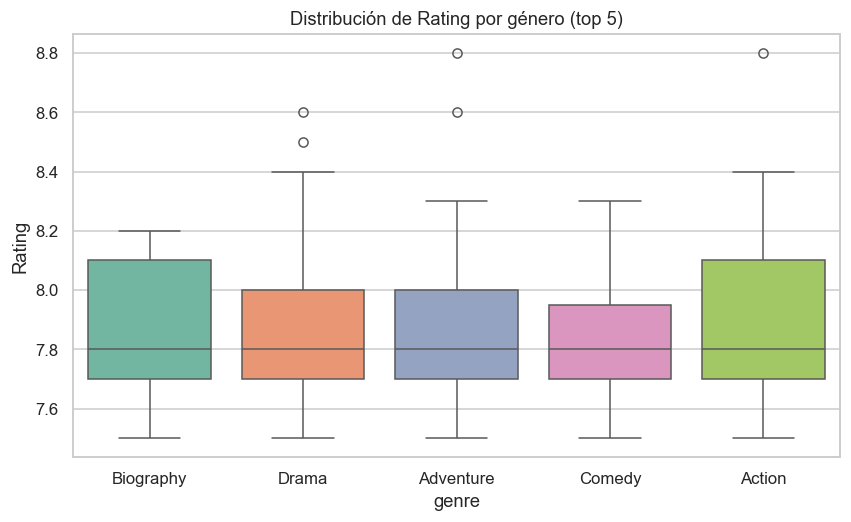

In [11]:
# Traer el género a nivel película (unir con genre, sacando vacíos)
genre_valid = genre[genre["genre"] != ""]
top5_generos = genre_valid["genre"].value_counts().head(5).index

df_genre = df.merge(genre_valid, on="Movie_id", how="inner")
df_genre_top5 = df_genre[df_genre["genre"].isin(top5_generos)]

plt.figure(figsize=(9,5))
sns.boxplot(data=df_genre_top5, x="genre", y="Rating", hue="genre", palette="Set2", legend=False)
plt.title("Distribución de Rating por género (top 5)")
plt.show()

*El género tiene POCO poder explicativo sobre la calidad*

## 5. Relaciones entre variables

Correlación entre presupuesto, recaudación, rating, duración y votos.

In [12]:
cols_corr = ["Budget", "Worldwide", "Domestic", "Rating", "Runtime", "TotalVotes", "MetaCritic"]
corr = df[cols_corr].corr()
corr.round(2)

,Budget,Worldwide,Domestic,Rating,Runtime,TotalVotes,MetaCritic
Budget,1.00,0.86,0.78,0.21,0.40,0.51,-0.21
Worldwide,0.86,1.00,0.96,0.29,0.32,0.58,-0.12
Domestic,0.78,0.96,1.00,0.26,0.27,0.54,-0.12
Rating,0.21,0.29,0.26,1.00,0.27,0.63,0.15
Runtime,0.40,0.32,0.27,0.27,1.00,0.42,-0.23
TotalVotes,0.51,0.58,0.54,0.63,0.42,1.00,-0.05
MetaCritic,-0.21,-0.12,-0.12,0.15,-0.23,-0.05,1.00


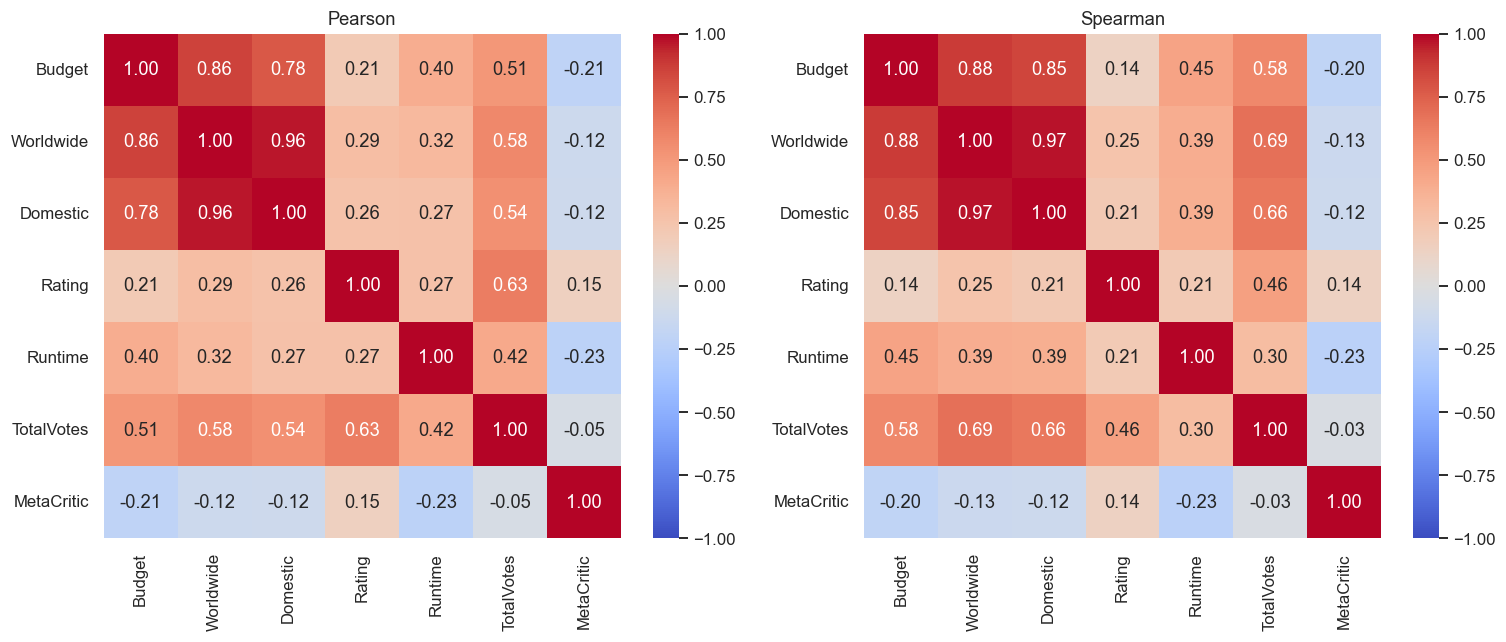

In [13]:
# Comparar Pearson vs Spearman
corr_spearman = df[cols_corr].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson")
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman")
plt.tight_layout()
plt.show()

*El dinero genera dinero, pero NO calidad. La calidad depende de aspectos creativos, no del presupuesto.*

- *Si inviertes MÁS dinero GANAS más dinero*

- *Si inviertes MÁS dinero NO necesariamente recibes mejor calificación*

- *Si GANAS más dinero NO necesariamente la película es mejor*

- *Si la película es MÁS POPULAR recibe MEJOR calificación*

- *Las películas MÁS LARGAS NO son necesariamente mejor calificadas*

- *Presupuesto alto Críticos profesionales MENOS entusiastas*



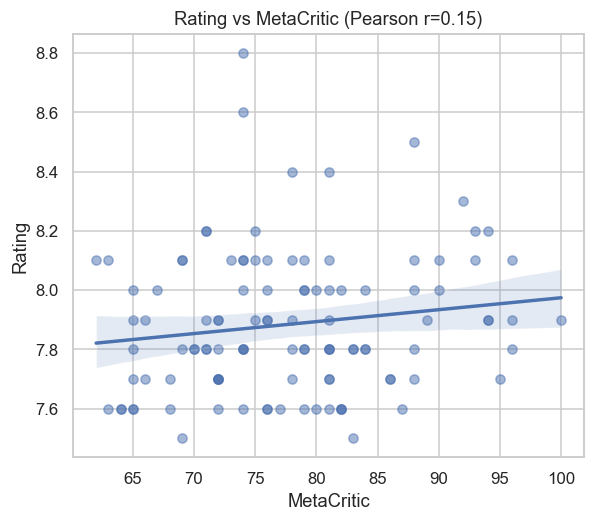

In [14]:
fig, ax = plt.subplots(figsize=(6,5))
sns.regplot(data=df, x="MetaCritic", y="Rating", scatter_kws={"alpha":0.5}, ax=ax)
ax.set_title(f"Rating vs MetaCritic (Pearson r={df['Rating'].corr(df['MetaCritic']):.2f})")
plt.show()

*Los críticos profesionales y el público NO coinciden en sus opiniones*


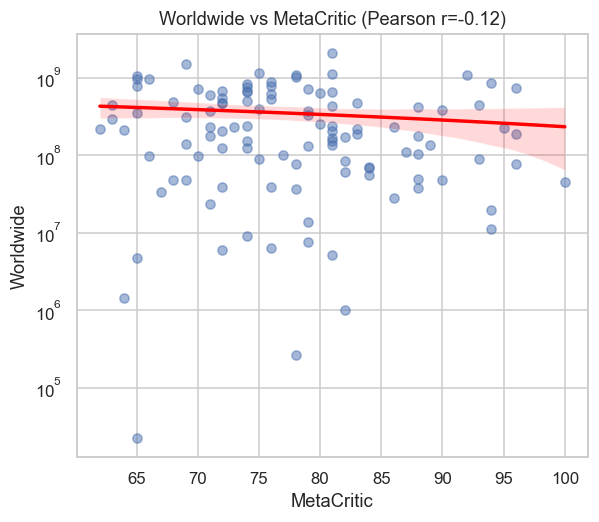

In [15]:
fig, ax = plt.subplots(figsize=(6,5))
sns.regplot(data=df, x="MetaCritic", y="Worldwide", scatter_kws={"alpha":0.5}, ax=ax, line_kws={"color":"red"})
ax.set_yscale("log")
ax.set_title(f"Worldwide vs MetaCritic (Pearson r={df['Worldwide'].corr(df['MetaCritic']):.2f})")
plt.show()

*Cuando los críticos califican MEJOR una película, TIENDE a ganar MENOS dinero*

## 6. Visualizaciones

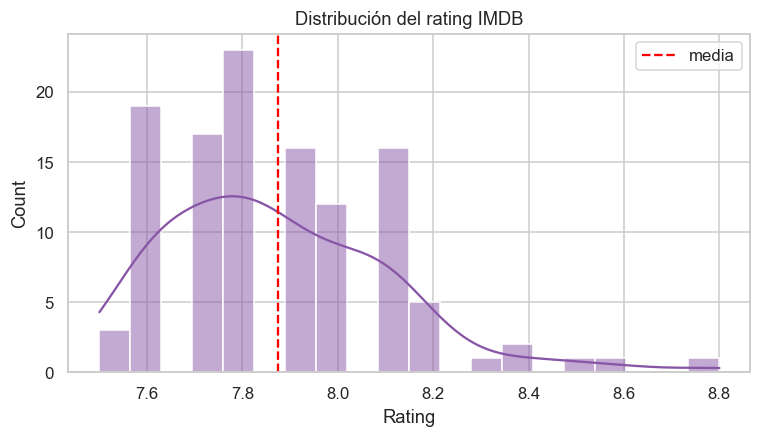

In [16]:
# Distribución del rating
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["Rating"], bins=20, kde=True, color="#8856a7", ax=ax)
ax.axvline(df["Rating"].mean(), color="red", ls="--", label="media")
ax.set_title("Distribución del rating IMDB")
ax.legend()
plt.show()

*Casi todas las películas se concentran entre 7.6 y 8.0 de rating; muy pocas superan 8.4.
La distribución tiene asimetría positiva y la media (línea roja) ronda 7.9. Es un dataset
de films ya "prestigiosos", con poco rango de rating.*

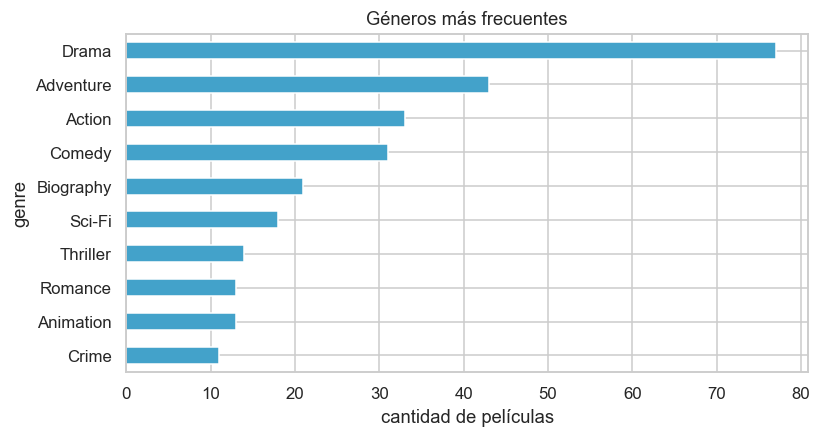

In [17]:
# Géneros más frecuentes
fig, ax = plt.subplots(figsize=(8, 4))
top_generos.sort_values().plot.barh(color="#43a2ca", ax=ax)
ax.set_title("Géneros más frecuentes")
ax.set_xlabel("cantidad de películas")
plt.show()

*Drama es por lejos el género más frecuente (77 películas), seguido de Adventure y Action.
Como cada película puede tener varios géneros (relación 1-a-muchos), la suma de las barras
supera la cantidad total de films.*

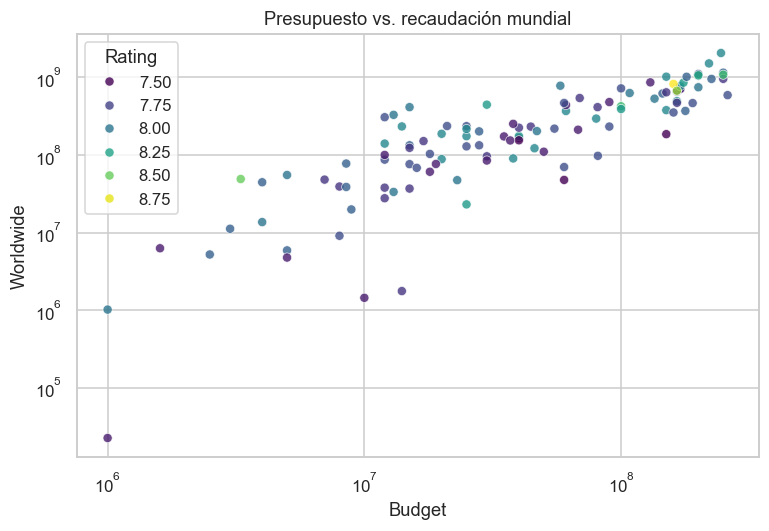

In [18]:
# Presupuesto vs recaudación mundial (escala log)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="Budget", y="Worldwide", hue="Rating",
                palette="viridis", alpha=0.8, ax=ax)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Presupuesto vs. recaudación mundial")
plt.show()

*En escala logarítmica se ve una relación positiva clara: a mayor presupuesto, mayor
recaudación mundial. El color (rating) no muestra un patrón marcado con la taquilla:
películas caras y taquilleras no son necesariamente las mejor puntuadas.*

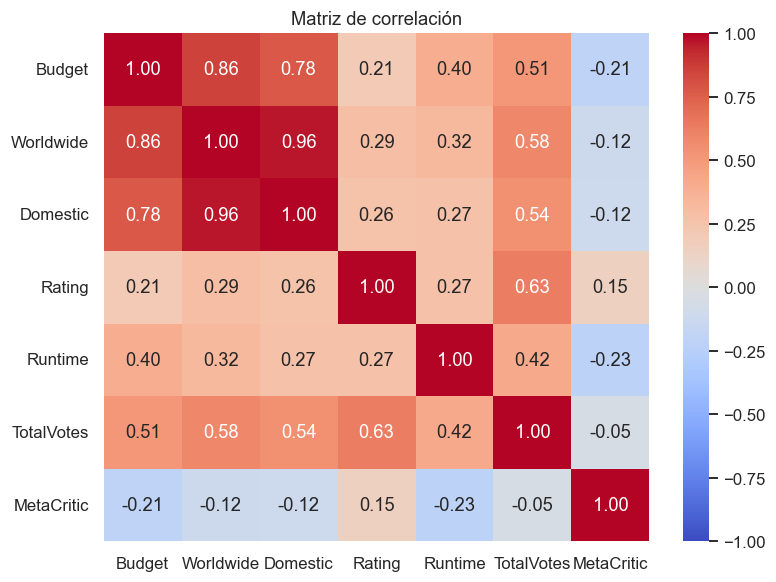

In [19]:
# Heatmap de correlación
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación")
plt.show()

*Budget y Worldwide están muy correlacionados (0.86), y Worldwide con Domestic casi de
forma perfecta (0.96). El rating correlaciona poco con la plata y algo más con la cantidad
de votos (0.63). MetaCritic aporta correlaciones bajas o negativas con lo comercial.*

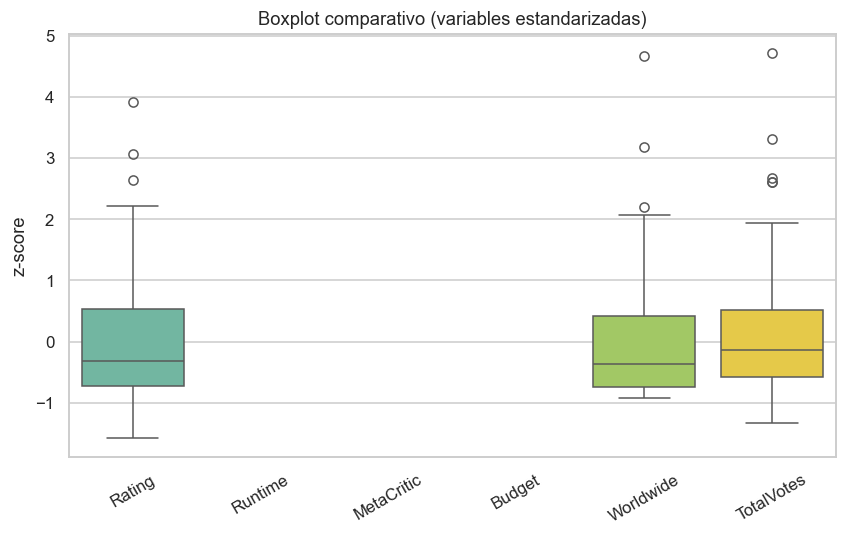

In [20]:
from scipy.stats import zscore

fig, ax = plt.subplots(figsize=(9,5))
df_z = df[num_foco].apply(zscore)
sns.boxplot(data=df_z, ax=ax, palette="Set2")
ax.set_title("Boxplot comparativo (variables estandarizadas)")
ax.set_ylabel("z-score")
plt.xticks(rotation=30)
plt.show()

*Este gráfico muestra que hay dos tipos de distribuciones. Rating, Runtime, MetaCritic y Budget tienen distribuciones normales, lo que significa que la mayoría de películas son similares. Sin embargo, Worldwide y TotalVotes tienen distribuciones sesgadas con muchos outliers, lo que indica que algunos blockbusters ganan MUCHÍSIMO más dinero y reciben muchos más votos que el promedio.*

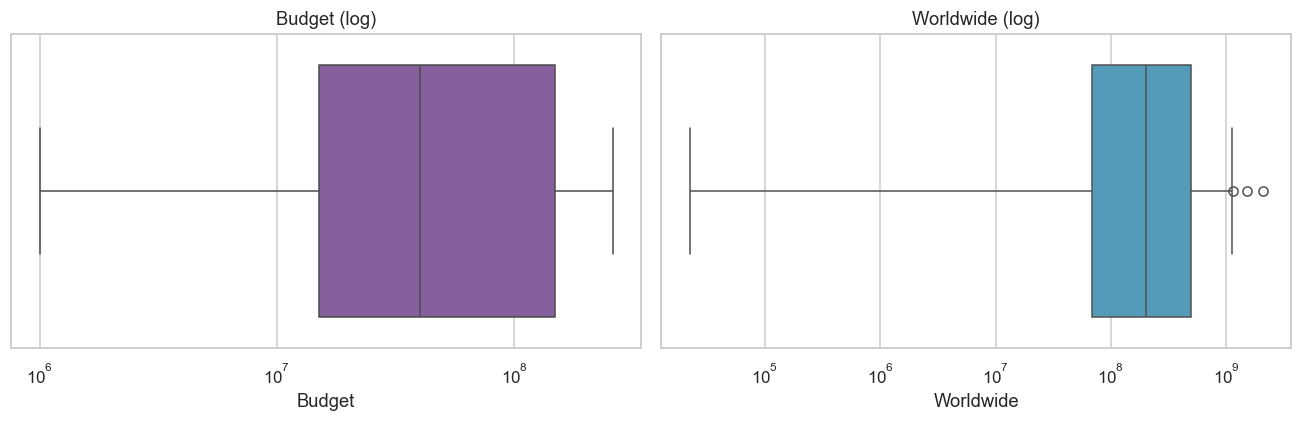

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Budget"], ax=axes[0], color="#8856a7")
axes[0].set_xscale("log")
axes[0].set_title("Budget (log)")
sns.boxplot(x=df["Worldwide"], ax=axes[1], color="#43a2ca")
axes[1].set_xscale("log")
axes[1].set_title("Worldwide (log)")
plt.tight_layout()
plt.show()

*Estos gráficos usan escala logarítmica, que es una forma especial de graficar números muy grandes juntos. En el Budget, la mayoría de películas cuestan entre 10M y 100M, y en escala logarítmica esto se ve como una distribución casi normal. Sin embargo, en Worldwide (ganancias), incluso en escala logarítmica, hay 2-3 películas que ganan MUCHÍSIMO más que el resto. Esto prueba que los outliers no son un error visual, sino un patrón REAL de la industria: algunos blockbusters dominan completamente las ganancias.*

## 7. Resumen para las diapositivas

In [22]:
resumen = {
    "peliculas": len(df),
    "columnas_totales": imdb.shape[1] + 2,  # IMDB + Domestic/Worldwide
    "num_numericas": df.select_dtypes("number").shape[1],
    "generos_unicos": genre[genre["genre"] != ""]["genre"].nunique(),
    "nulos_MetaCritic": int(df["MetaCritic"].isna().sum()),
    "nulos_Budget": int(df["Budget"].isna().sum()),
    "nulos_Runtime": int(df["Runtime"].isna().sum()),
    "generos_vacios": int((genre["genre"] == "").sum()),
    "top_genero": top_generos.index[0],
    "mas_votada": df.loc[df["TotalVotes"].idxmax(), "Title"],
    "mayor_recaudacion": df.loc[df["Worldwide"].idxmax(), "Title"],
    "rating_promedio": round(df["Rating"].mean(), 1),
}
for k, v in resumen.items():
    print(f"{k}: {v}")

peliculas: 117
columnas_totales: 54
num_numericas: 7
generos_unicos: 20
nulos_MetaCritic: 7
nulos_Budget: 3
nulos_Runtime: 21
generos_vacios: 41
top_genero: Drama
mas_votada: Inception (2010)
mayor_recaudacion: Star Wars: The Force Awakens (2015)
rating_promedio: 7.9


In [23]:
# Momentos estadísticos para todas las variables numéricas de interés
momentos = pd.DataFrame({
    "media": df[num_foco].mean(),
    "mediana": df[num_foco].median(),
    "desv_std": df[num_foco].std(),
    "skew": df[num_foco].skew(),
    "kurtosis": df[num_foco].kurt(),
}).round(2)
momentos



,media,mediana,desv_std,skew,kurtosis
Rating,7.870000e+00,7.8,2.400000e-01,1.00,1.59
Runtime,1.265600e+02,125.5,1.965000e+01,0.45,-0.25
MetaCritic,7.781000e+01,77.5,8.860000e+00,0.38,-0.46
Budget,7.459649e+07,40000000.0,7.507881e+07,0.94,-0.44
Worldwide,3.403780e+08,201634991.0,3.719455e+08,1.67,3.57
TotalVotes,3.755791e+05,337571.0,2.627056e+05,1.62,4.47


# EDA - AVANZADO

Esta sección extiende el **EDA base** aplicando las técnicas de **Clase 3** (medidas de asociación por tipo de variable, tests de hipótesis, causas de faltantes, detección cuantitativa de outliers y entropía) y **Clase 4** (split, imputación, tratamiento de outliers y codificación).

In [24]:
# Instalación de librerías usadas en las clases (si ya están, no reinstala nada)
!pip install -q missingno scikit-learn category_encoders

import missingno as msno
from scipy.stats import f_oneway, pearsonr, spearmanr, kendalltau, entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Reutilizamos df, genre y las listas de columnas del EDA base
num_foco = ["Rating", "Runtime", "MetaCritic", "Budget", "Worldwide", "TotalVotes"]
cols_corr = ["Budget", "Worldwide", "Domestic", "Rating", "Runtime", "TotalVotes", "MetaCritic"]

# Género a nivel PELÍCULA: tomamos el género principal (el primero listado del film),
# necesario para las medidas numérica–categórica y el ANOVA.
genre_valid = genre[genre["genre"].str.strip() != ""].copy()
gen_principal = (genre_valid.sort_values("Movie_id")
                 .groupby("Movie_id")["genre"].first().rename("genre_principal"))
df_av = df.merge(gen_principal, on="Movie_id", how="left")
print("df_av:", df_av.shape, "| películas con género principal:", int(df_av["genre_principal"].notna().sum()))


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


df_av: (117, 55) | películas con género principal: 117


## Clase 3 — Análisis exploratorio avanzado

### 3.1 Medidas de asociación
La medida correcta depende del tipo de variable. Para **numérica–numérica** usamos Pearson (relación lineal), Spearman y Kendall (monótonas, por rangos). Para **numérica–categórica** usamos **η² (eta cuadrado)**: qué proporción de la varianza de la numérica explica la categoría (0 = nada; ≥0.14 = fuerte).

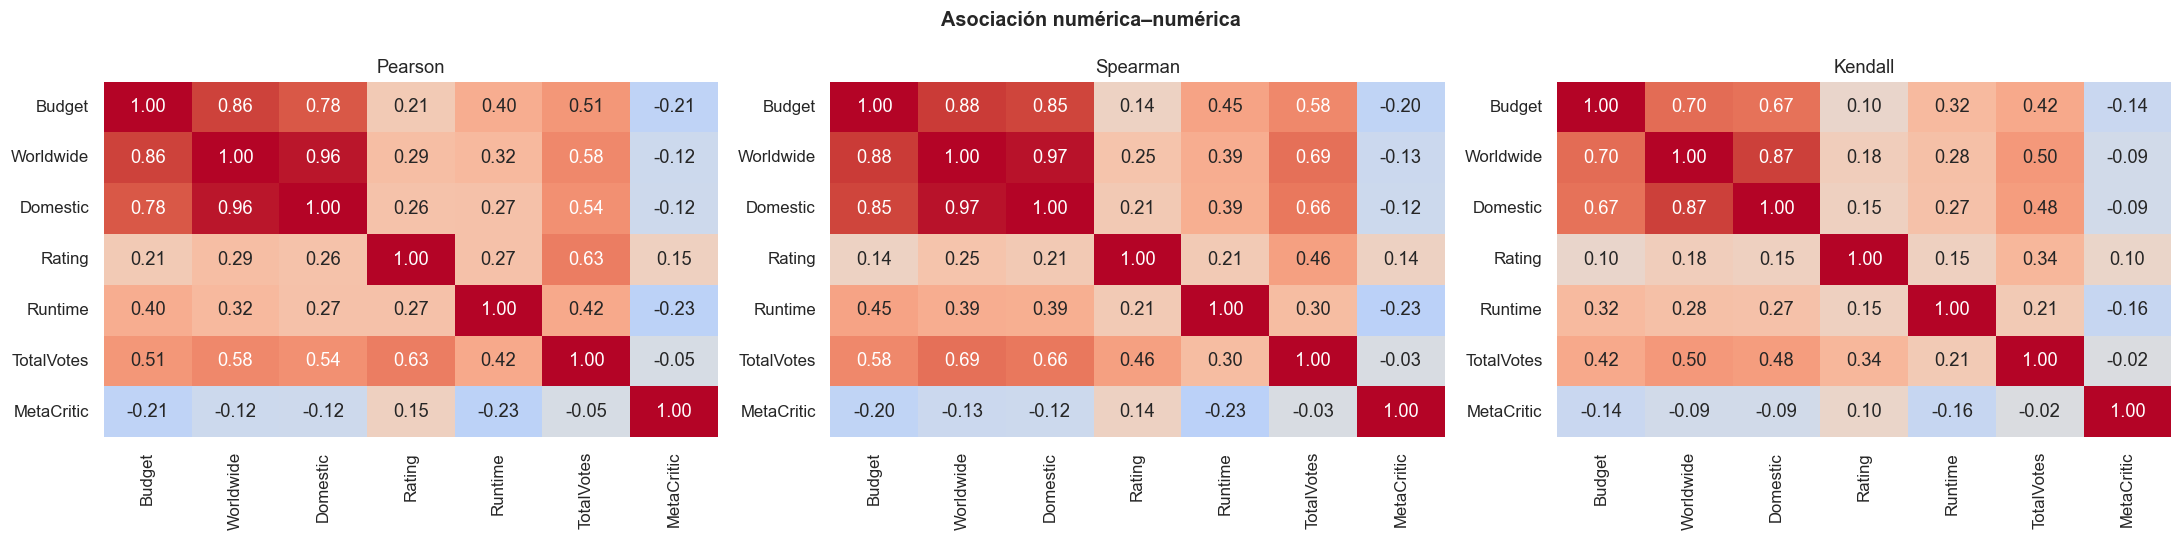

η² de cada variable numérica respecto del género principal:
Budget        0.517
Worldwide     0.455
TotalVotes    0.228
Runtime       0.216
Rating        0.112
MetaCritic    0.101

Escala: <0.01 despreciable | 0.01-0.06 débil | 0.06-0.14 moderada | >=0.14 fuerte


In [25]:
# --- Numérica–Numérica: Pearson, Spearman y Kendall ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, m in zip(axes, ["pearson", "spearman", "kendall"]):
    sns.heatmap(df[cols_corr].corr(method=m), annot=True, fmt=".2f",
                cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax, cbar=False)
    ax.set_title(m.capitalize())
plt.suptitle("Asociación numérica–numérica", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# --- Numérica–Categórica: eta cuadrado (correlation ratio) vs género principal ---
def eta_squared(categorias, valores):
    # η²: proporción de la varianza de 'valores' explicada por los grupos de 'categorias'
    d = pd.DataFrame({"g": categorias, "y": valores}).dropna()
    grupos = [g["y"].values for _, g in d.groupby("g") if len(g) > 1]
    if len(grupos) < 2:
        return np.nan
    media_global = d["y"].mean()
    ss_total = ((d["y"] - media_global) ** 2).sum()
    ss_between = sum(len(g) * (g.mean() - media_global) ** 2 for g in grupos)
    return ss_between / ss_total if ss_total > 0 else np.nan

eta = (pd.Series({v: eta_squared(df_av["genre_principal"], df_av[v]) for v in num_foco},
                 name="eta_cuadrado").sort_values(ascending=False).round(3))
print("η² de cada variable numérica respecto del género principal:")
print(eta.to_string())
print("\nEscala: <0.01 despreciable | 0.01-0.06 débil | 0.06-0.14 moderada | >=0.14 fuerte")

*Kendall y Spearman confirman las relaciones monótonas que ya mostraba Pearson. El η² del género sobre `Rating` es bajo: el género explica muy poca variabilidad de la calificación.*

### 3.2 Tests de hipótesis
Un test formaliza si una asociación observada es real o producto del azar muestral. Fijamos H0 (no hay relación) vs H1 (sí la hay) y un nivel α=0.05: si el **p-valor < α** se rechaza H0. Con n=117 (muestra chica) los tests tienen poca potencia, así que un p alto no "prueba" ausencia de efecto.

In [26]:
alpha = 0.05

# --- Numérica–Numérica: significancia de las correlaciones (r y p-valor) ---
pares = [("Budget", "Worldwide"), ("Budget", "Rating"), ("Rating", "MetaCritic"),
         ("Rating", "TotalVotes"), ("Worldwide", "MetaCritic")]
filas = []
for a, b in pares:
    d = df[[a, b]].dropna()
    r_p, p_p = pearsonr(d[a], d[b])
    r_s, p_s = spearmanr(d[a], d[b])
    filas.append({"par": a + "-" + b, "n": len(d),
                  "Pearson r": round(r_p, 3), "p (Pearson)": round(p_p, 4),
                  "Spearman r": round(r_s, 3), "p (Spearman)": round(p_s, 4),
                  "signif. (a=0.05)": "Sí" if p_p < alpha else "No"})
print("H0: r = 0 (no hay correlación)   |   H1: r != 0")
display(pd.DataFrame(filas))

# --- Numérica–Categórica: ANOVA de Rating entre géneros principales ---
top_gen = df_av["genre_principal"].value_counts().head(6).index
grupos = [g["Rating"].dropna().values
          for _, g in df_av[df_av["genre_principal"].isin(top_gen)].groupby("genre_principal")]
F, p_anova = f_oneway(*grupos)
print("\nANOVA - H0: el Rating medio es igual en todos los géneros | H1: al menos uno difiere")
print(f"F = {F:.3f} | p-valor = {p_anova:.4f}  ->  "
      + ("se RECHAZA H0: hay diferencias de Rating entre géneros"
         if p_anova < alpha else "NO se rechaza H0: sin evidencia de diferencias de Rating entre géneros"))

H0: r = 0 (no hay correlación)   |   H1: r != 0


,par,n,Pearson r,p (Pearson),Spearman r,p (Spearman),signif. (a=0.05)
0,Budget-Worldwide,114,0.859,0.0000,0.875,0.0000,Sí
1,Budget-Rating,114,0.211,0.0243,0.137,0.1457,Sí
2,Rating-MetaCritic,110,0.149,0.1192,0.142,0.1390,No
3,Rating-TotalVotes,117,0.625,0.0000,0.464,0.0000,Sí
4,Worldwide-MetaCritic,110,-0.122,0.2044,-0.132,0.1684,No



ANOVA - H0: el Rating medio es igual en todos los géneros | H1: al menos uno difiere
F = 1.266 | p-valor = 0.2862  ->  NO se rechaza H0: sin evidencia de diferencias de Rating entre géneros


*Los p-valores indican cuáles correlaciones son significativas y cuáles no se distinguen de cero. El ANOVA evalúa lo mismo para la relación género–calidad.*

### 3.3 Datos faltantes: identificación y causas
No alcanza con contar nulos: hay que diagnosticar **por qué** faltan. **MCAR** (falta al azar, sin sesgo), **MAR** (la falta depende de otras columnas observadas), **MNAR** (depende del propio valor no visto) y **estructural** (el dato no existe). El mecanismo determina cómo tratarlos.

% de faltantes por columna:
Runtime       17.95
MetaCritic     5.98
Budget         2.56
Rating         0.00
Worldwide      0.00
TotalVotes     0.00


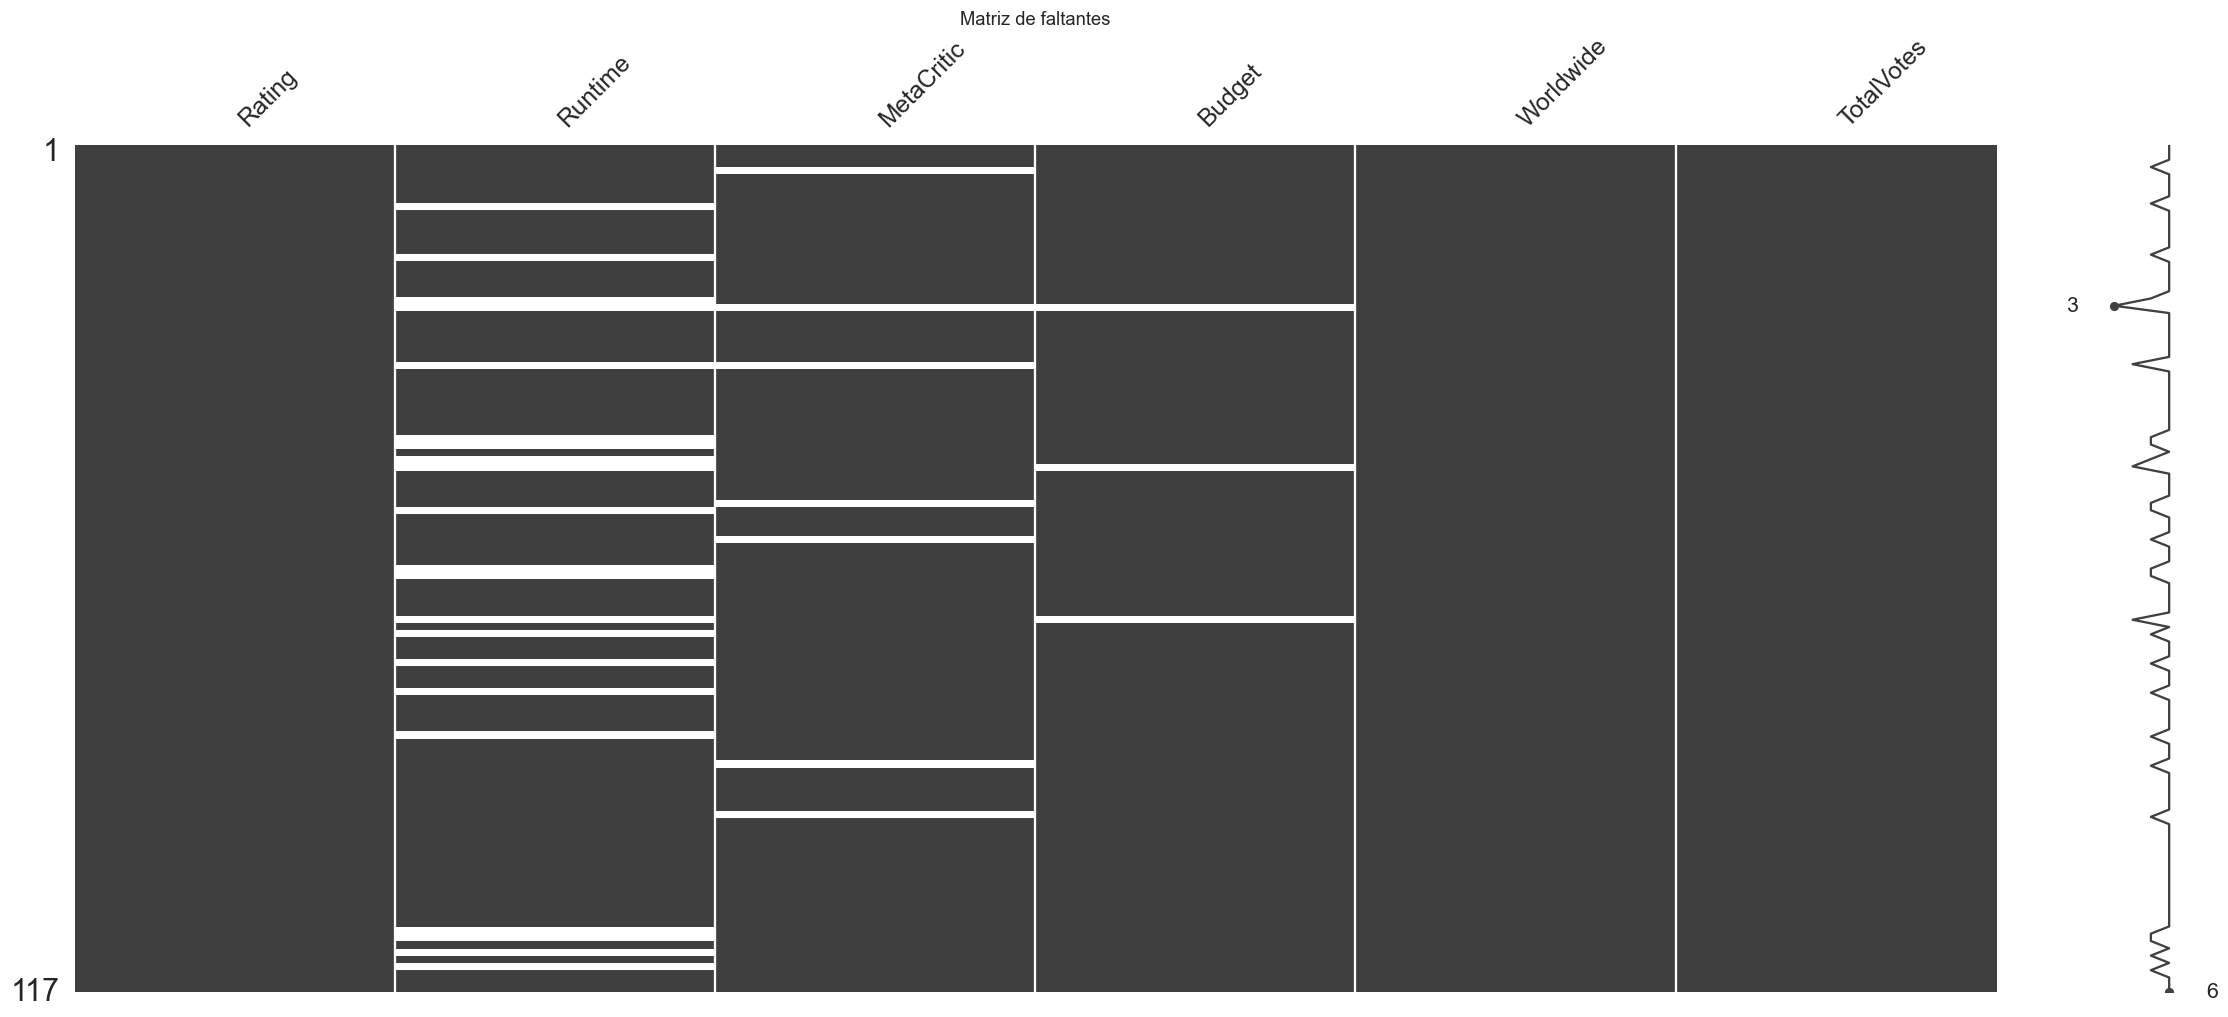

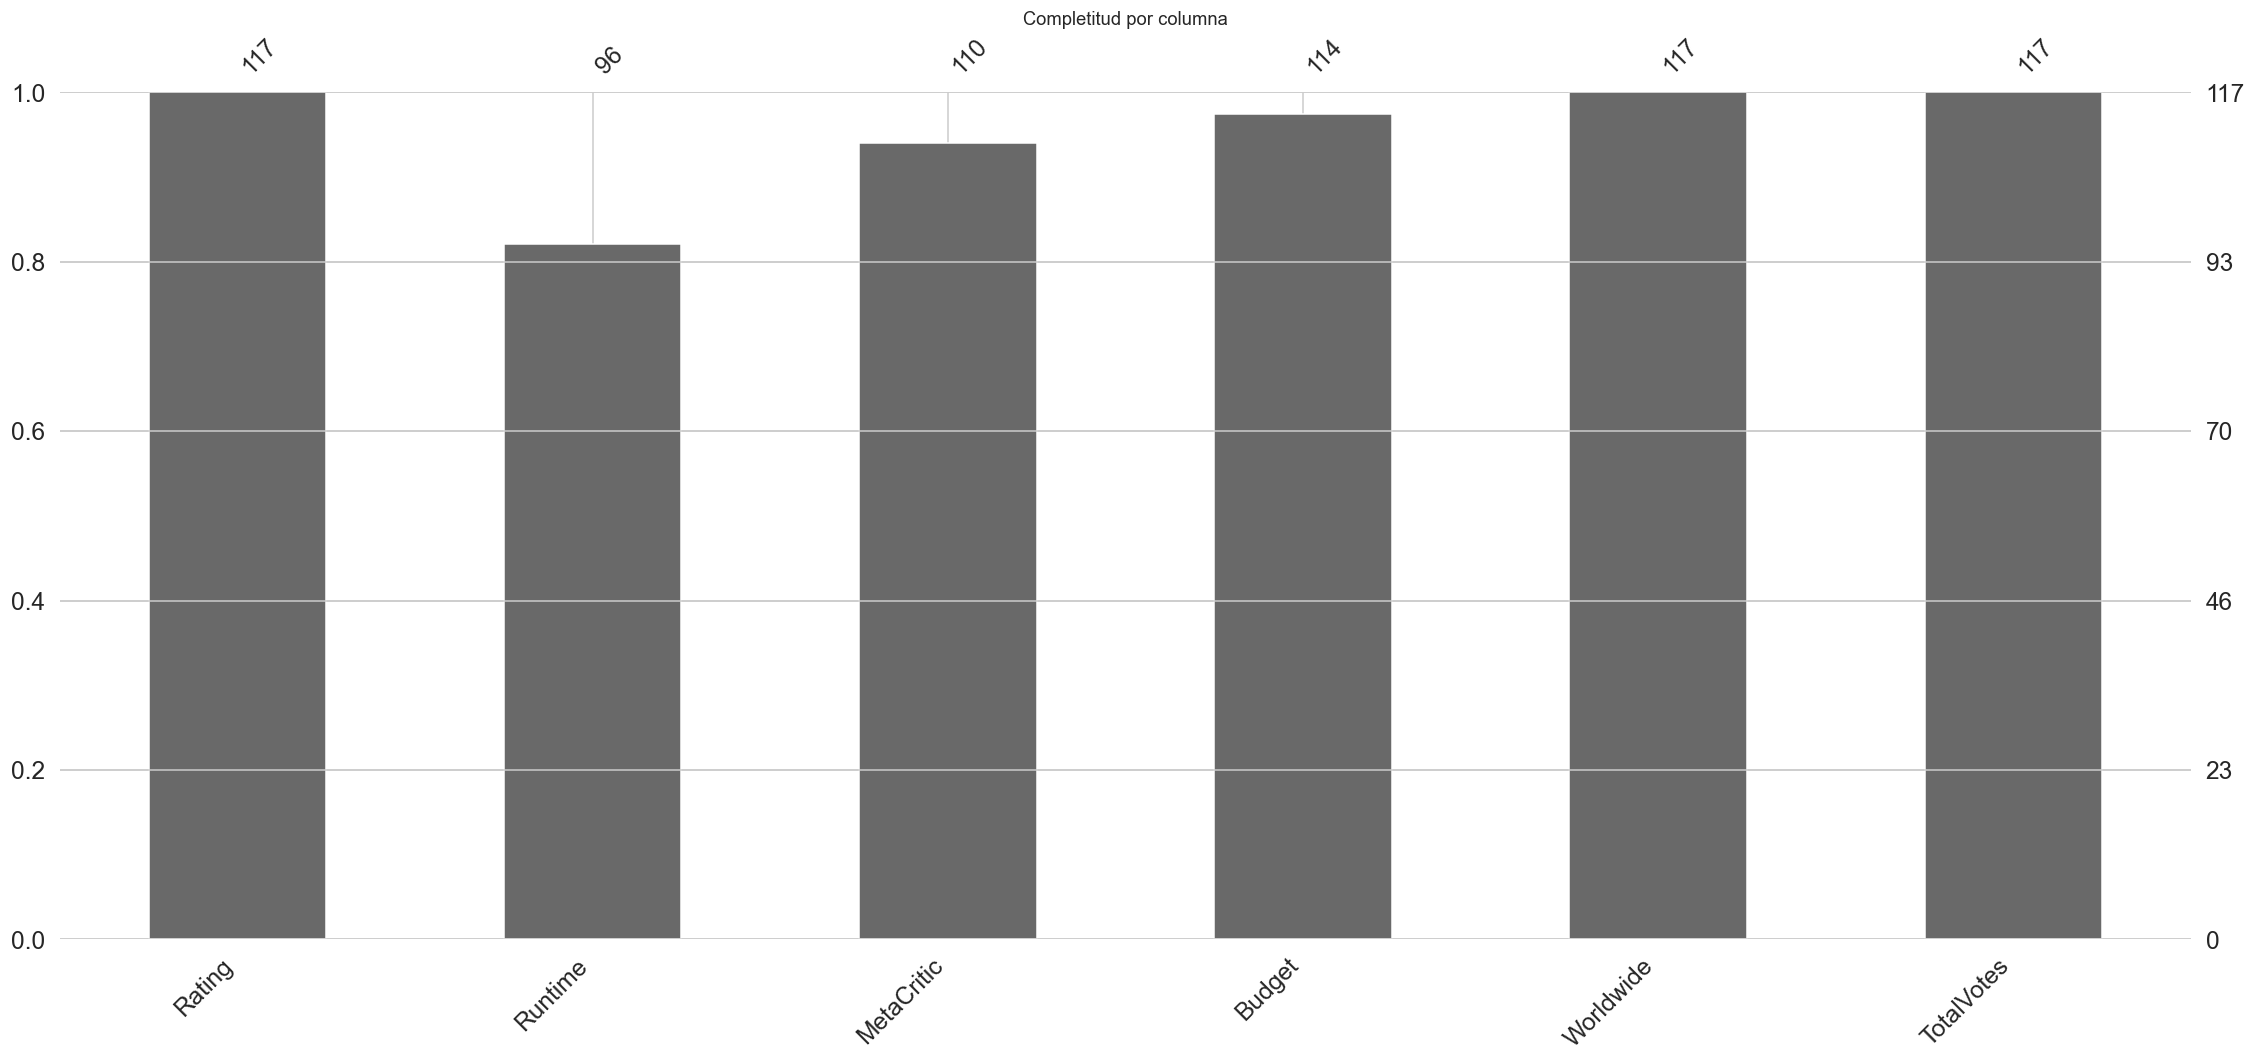

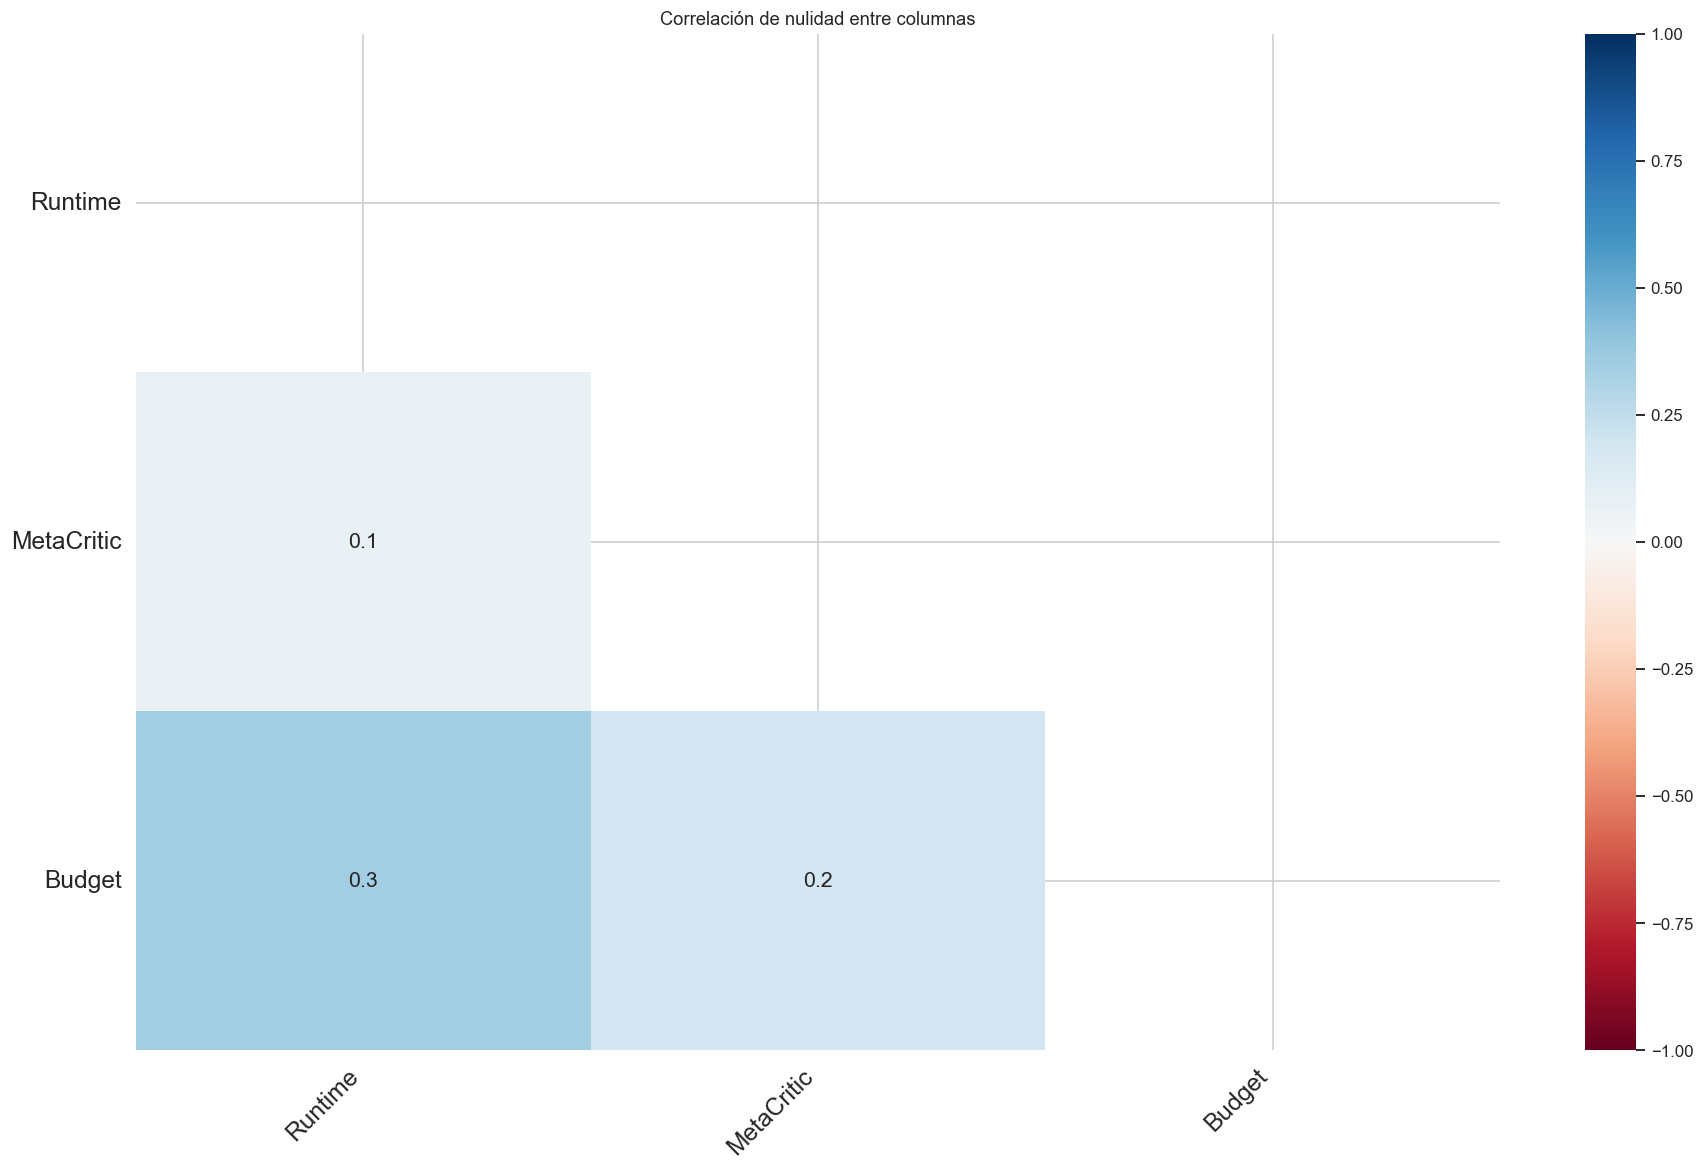

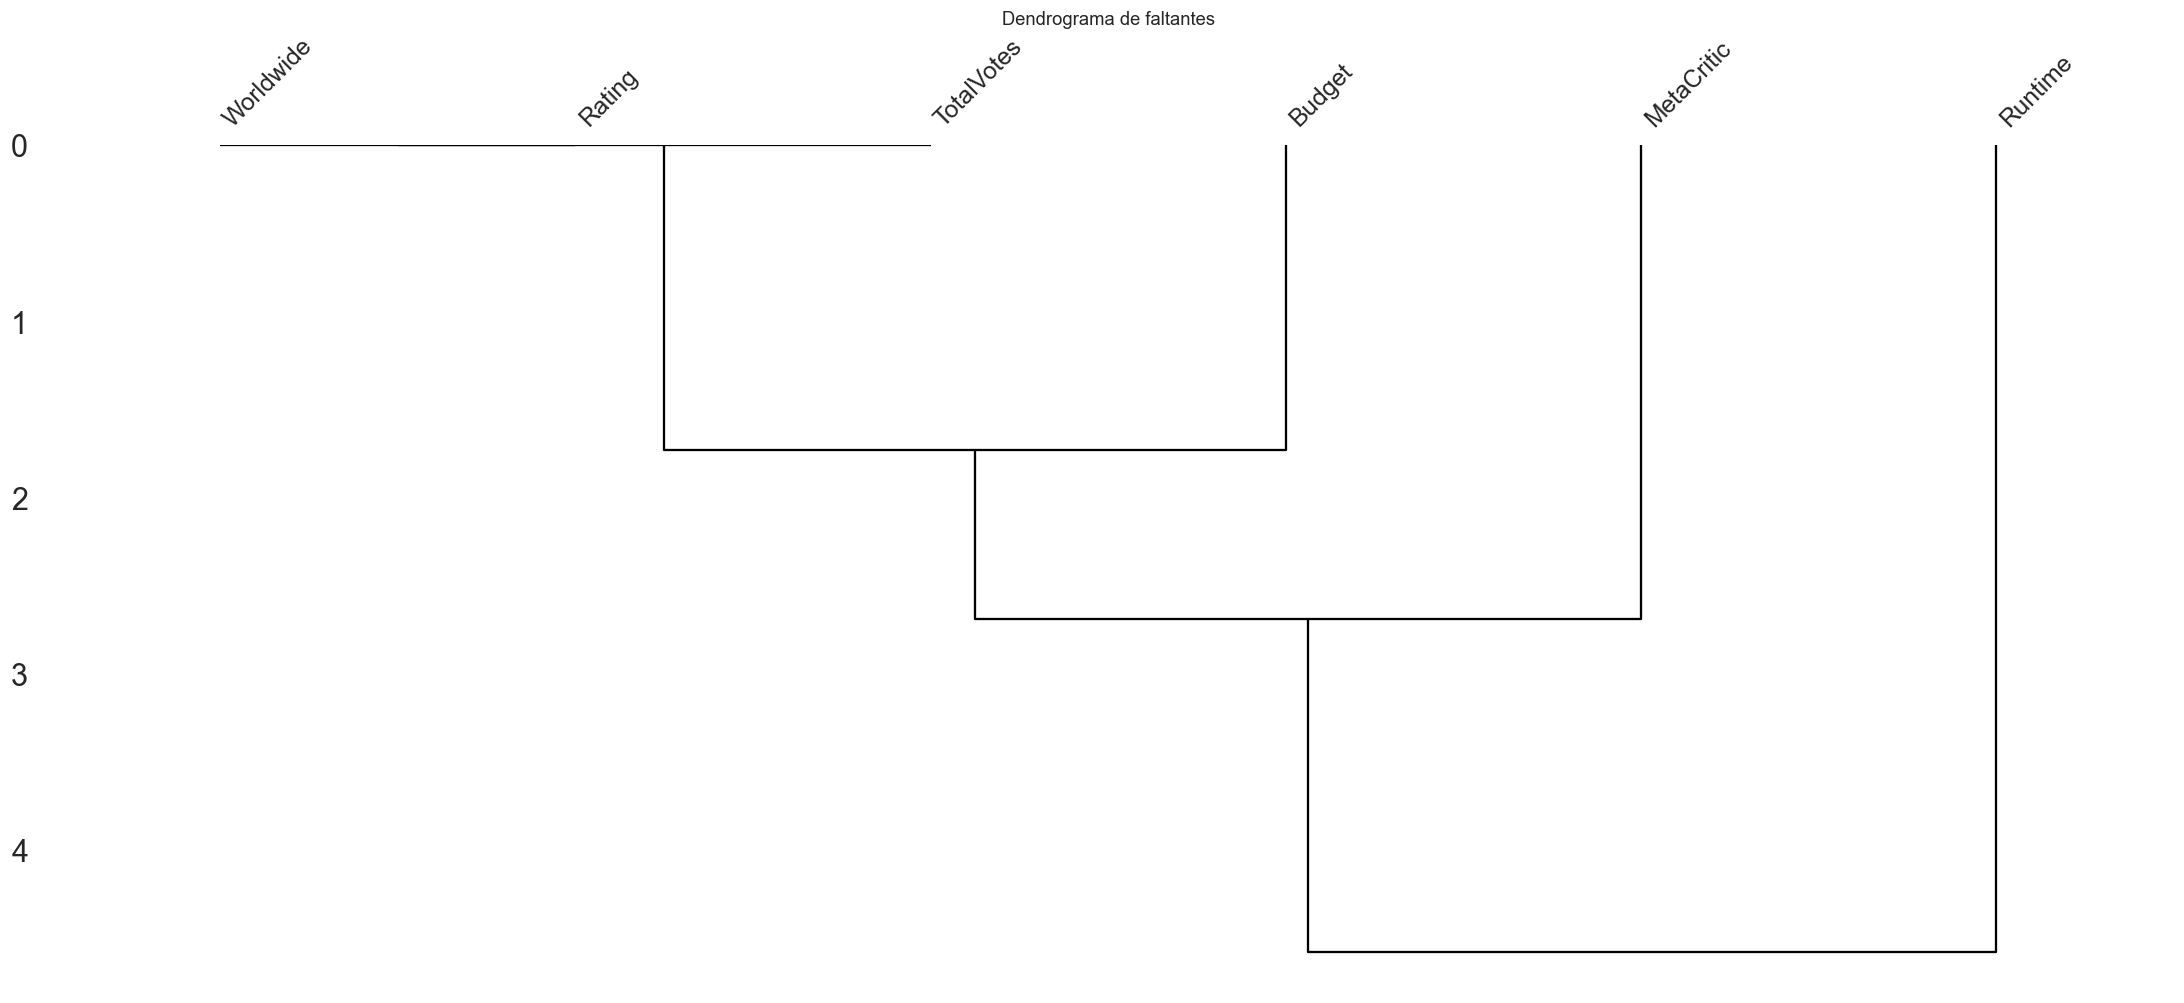

In [27]:
# % de faltantes por columna
faltantes = (df[num_foco].isna().mean() * 100).round(2).sort_values(ascending=False)
print("% de faltantes por columna:"); print(faltantes.to_string())

# Patrones de faltantes con missingno
msno.matrix(df[num_foco]); plt.title("Matriz de faltantes"); plt.show()
msno.bar(df[num_foco]); plt.title("Completitud por columna"); plt.show()
msno.heatmap(df[num_foco]); plt.title("Correlación de nulidad entre columnas"); plt.show()
msno.dendrogram(df[num_foco]); plt.title("Dendrograma de faltantes"); plt.show()

% de faltantes por género principal:


,Runtime,MetaCritic,Budget
genre_principal,,,
Horror,100.0,0.0,0.0
Family,50.0,0.0,0.0
Comedy,28.6,0.0,0.0
Romance,28.6,14.3,0.0
Adventure,25.0,5.0,0.0
Drama,21.6,8.1,8.1
Action,8.3,0.0,0.0
Musical,0.0,0.0,0.0
Thriller,0.0,0.0,0.0



% de faltantes por década:


,Runtime,MetaCritic,Budget
decada,,,
2010.0,17.9,6.0,2.6


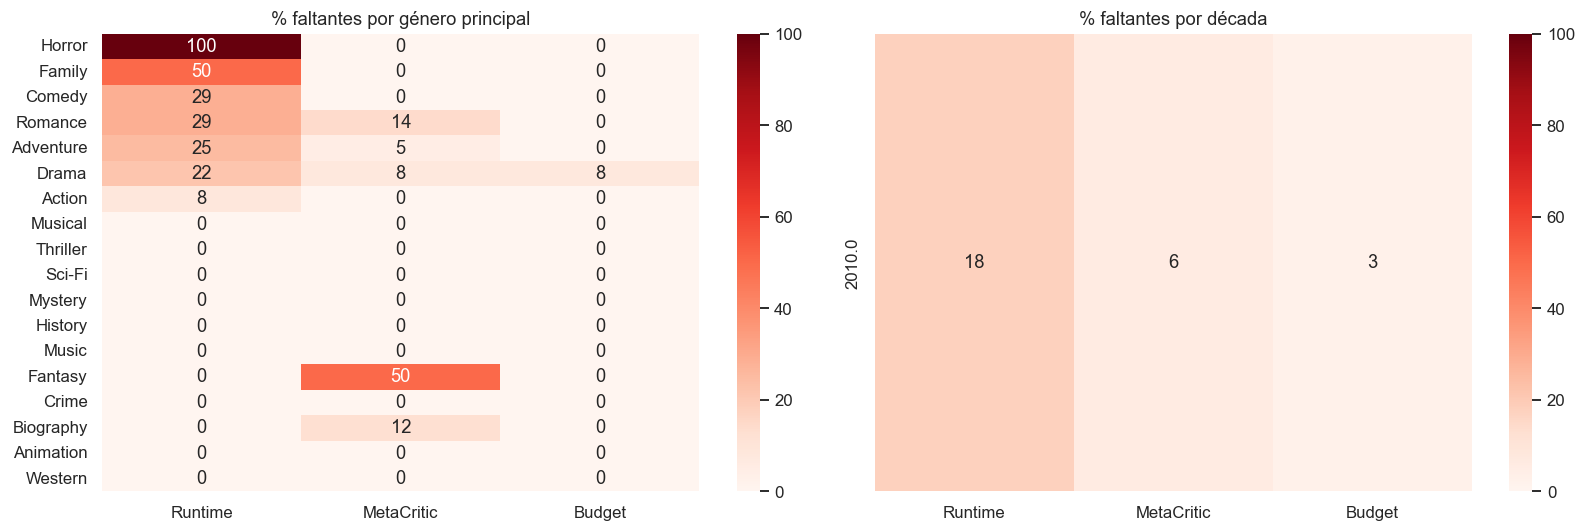

In [28]:
# ¿Los faltantes dependen de otra variable observada? -> pista MCAR vs MAR
# Extraemos el año del título (IMDB lo guarda ahí) y agrupamos por década.
df_av["anio"] = df_av["Title"].str.extract(r"\((\d{4})\)").astype(float)
df_av["decada"] = (df_av["anio"] // 10 * 10)

cols_falt = ["Runtime", "MetaCritic", "Budget"]

# % de faltantes de cada variable por cada categoría de GÉNERO principal
falt_genero = (df_av.groupby("genre_principal")[cols_falt]
               .apply(lambda g: g.isna().mean() * 100).round(1)
               .sort_values("Runtime", ascending=False))
print("% de faltantes por género principal:")
display(falt_genero)

# % de faltantes de cada variable por cada DÉCADA
falt_decada = (df_av.dropna(subset=["decada"]).groupby("decada")[cols_falt]
               .apply(lambda g: g.isna().mean() * 100).round(1))
print("\n% de faltantes por década:")
display(falt_decada)

# Heatmaps: dónde se concentra la falta de cada variable
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(falt_genero, annot=True, fmt=".0f", cmap="Reds", vmin=0, vmax=100, ax=axes[0])
axes[0].set_title("% faltantes por género principal"); axes[0].set_ylabel("")
sns.heatmap(falt_decada, annot=True, fmt=".0f", cmap="Reds", vmin=0, vmax=100, ax=axes[1])
axes[1].set_title("% faltantes por década"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

**Mecanismo probable por columna:**
- **`Runtime` (18%)**: si los nulos se concentran en ciertas décadas/géneros → **MAR** (falta ligada a la antigüedad del film); si están repartidos → MCAR.
- **`MetaCritic` (6%)**: Metacritic no puntúa todas las películas (indies/antiguas) → probable **MAR / estructural**.
- **`Budget` (2.6%)**: pocos casos y sin patrón claro → tratable como **MCAR**.

### 3.4 Detección cuantitativa de outliers
Además de verlos en el boxplot, los cuantificamos con dos reglas: **IQR** (fuera de [Q1−1.5·IQR, Q3+1.5·IQR], robusta, no asume distribución) y **±3σ** (fuera de media±3·desvío, asume normalidad). Comparar ambas ayuda a distinguir colas pesadas de errores.

,n,IQR_out,%IQR,3s_out,lim_inf_IQR,lim_sup_IQR
Rating,117.0,3.0,2.6,2.0,7.2,8.400000e+00
Runtime,96.0,1.0,1.0,0.0,74.5,1.765000e+02
MetaCritic,110.0,1.0,0.9,0.0,55.9,9.890000e+01
Budget,114.0,0.0,0.0,0.0,-185625000.0,3.493750e+08
Worldwide,117.0,3.0,2.6,2.0,-571660223.5,1.134802e+09
TotalVotes,117.0,5.0,4.3,2.0,-212931.5,9.478005e+05


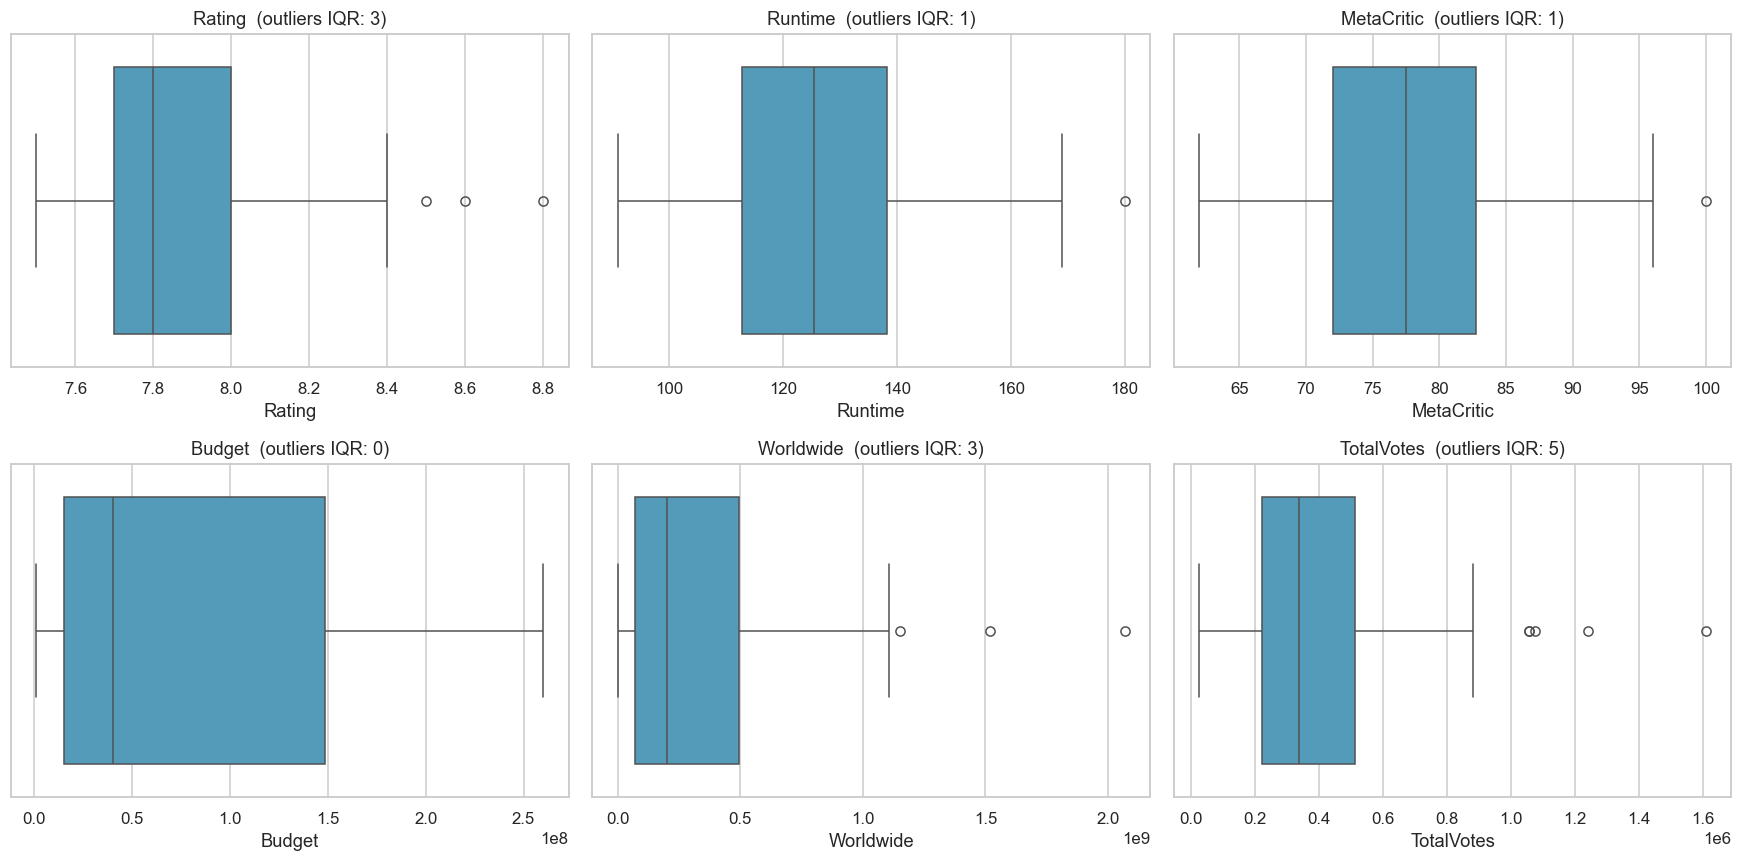

In [29]:
def contar_outliers(s):
    s = s.dropna()
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    m, sd = s.mean(), s.std()
    n_iqr = int(((s < lo) | (s > hi)).sum())
    n_3s = int(((s < m - 3 * sd) | (s > m + 3 * sd)).sum())
    return pd.Series({"n": len(s), "IQR_out": n_iqr, "%IQR": round(100 * n_iqr / len(s), 1),
                      "3s_out": n_3s, "lim_inf_IQR": round(lo, 1), "lim_sup_IQR": round(hi, 1)})

resumen_out = pd.DataFrame({v: contar_outliers(df[v]) for v in num_foco}).T
display(resumen_out)

# Boxplots con el conteo de outliers IQR en el título
fig, axes = plt.subplots(2, 3, figsize=(16, 8)); axes = axes.flatten()
for ax, v in zip(axes, num_foco):
    sns.boxplot(x=df[v], ax=ax, color="#43a2ca")
    ax.set_title(f"{v}  (outliers IQR: {int(resumen_out.loc[v, 'IQR_out'])})")
plt.tight_layout(); plt.show()

In [30]:
# Detalle de cada registro outlier (regla IQR): película, valor y media/mediana de la columna
def fmt(x):
    return f"{x:,.1f}" if abs(x) < 1000 else f"{x:,.0f}"

detalle = []
for v in num_foco:
    s = df[v]
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = ((s < lo) | (s > hi)).fillna(False)
    for idx in df.index[mask]:
        detalle.append({
            "Title": df.loc[idx, "Title"],
            "columna": v,
            "_orden": float(df.loc[idx, v]),
            "valor_outlier": fmt(float(df.loc[idx, v])),
            "media_col": fmt(s.mean()),
            "mediana_col": fmt(s.median()),
            "lim_inf_IQR": fmt(lo),
            "lim_sup_IQR": fmt(hi),
        })
detalle_out = (pd.DataFrame(detalle)
               .sort_values(["columna", "_orden"], ascending=[True, False])
               .drop(columns="_orden").reset_index(drop=True))
print(f"{len(detalle_out)} registros outlier por IQR:")
display(detalle_out)

13 registros outlier por IQR:


,Title,columna,valor_outlier,media_col,mediana_col,lim_inf_IQR,lim_sup_IQR
0,Boyhood (2014),MetaCritic,100.0,77.8,77.5,55.9,98.9
1,Inception (2010),Rating,8.8,7.9,7.8,7.2,8.4
2,Interstellar (2014),Rating,8.6,7.9,7.8,7.2,8.4
3,Whiplash (2014),Rating,8.5,7.9,7.8,7.2,8.4
4,The Wolf of Wall Street (2013),Runtime,180.0,126.6,125.5,74.5,176.5
5,Inception (2010),TotalVotes,"1,609,713","375,579","337,571","-212,932","947,800"
6,The Dark Knight Rises (2012),TotalVotes,"1,240,780","375,579","337,571","-212,932","947,800"
7,Interstellar (2014),TotalVotes,"1,075,163","375,579","337,571","-212,932","947,800"
8,Django Unchained (2012),TotalVotes,"1,056,822","375,579","337,571","-212,932","947,800"
9,The Avengers (2012),TotalVotes,"1,056,773","375,579","337,571","-212,932","947,800"


Si bien existen outliers, parecen ser datos reales y precisos, por lo que analizaremos tecnicas de normalizacion mas adelante.

### 3.5 Entropía de Shannon
La entropía mide la **diversidad** de una variable categórica (en bits). Se compara con la máxima posible, H_max = log2(k): **H/H_max ≈ 1** indica categorías repartidas parejo; **≈ 0** indica que una domina. Es a las categóricas lo que el desvío estándar a las numéricas.

Géneros válidos (k): 20
Entropía H = 3.548 bits | H_max = 4.322 bits | H/H_max = 0.821
-> distribución diversa (categorías parejas)


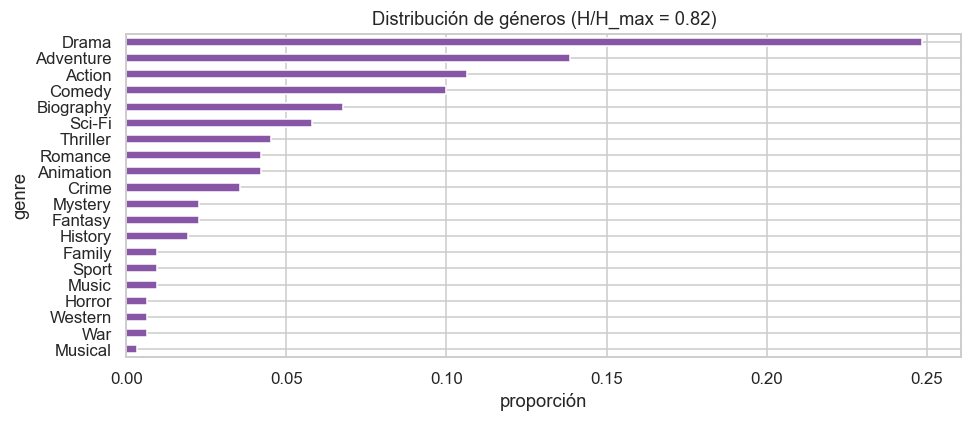

In [31]:
p = genre_valid["genre"].value_counts(normalize=True)
H = entropy(p, base=2); H_max = np.log2(len(p))
print(f"Géneros válidos (k): {len(p)}")
print(f"Entropía H = {H:.3f} bits | H_max = {H_max:.3f} bits | H/H_max = {H / H_max:.3f}")
print("-> " + ("distribución diversa (categorías parejas)" if H / H_max > 0.8
               else "distribución concentrada: pocos géneros dominan (Drama, Adventure, Action)"))

fig, ax = plt.subplots(figsize=(9, 4))
p.sort_values().plot.barh(color="#8856a7", ax=ax)
ax.set_title(f"Distribución de géneros (H/H_max = {H / H_max:.2f})"); ax.set_xlabel("proporción")
plt.tight_layout(); plt.show()

Detectamos un desbalance enntre las distintas categorias, por lo que procederemos a agrupar las cateogiras de monor ocurrencia mas adelante.

## Clase 4 — Preparación de datos

### 4.1 Split train/test (primero, antes de preparar)
El split se hace **antes** de imputar/tratar/codificar para evitar *data leakage*: los parámetros (mediana, límites, categorías) se aprenden **solo en train** y se aplican a test. La estratificación (`stratify`) aplica a clasificación; como `Rating` es continuo, hacemos un split aleatorio simple 80/20.

In [32]:
train_df, test_df = train_test_split(df_av.copy(), test_size=0.2, random_state=42)
print(f"train: {train_df.shape[0]} filas | test: {test_df.shape[0]} filas")

train: 93 filas | test: 24 filas


### 4.2 Imputación de faltantes (aprendida en train)
Regla causa × cantidad: con faltantes bajos/medios y mecanismo MCAR/MAR imputamos con un estadístico; con >70% se elimina la columna. Usamos la **mediana** por ser robusta a la asimetría de estas variables. Se calcula sobre train y se aplica a train y test, para no filtrar información del test (leakage).

Medianas aprendidas en train:
Budget        40000000.0
MetaCritic          77.0
Runtime            122.5

Nulos tras imputar -> train: 0 | test: 0


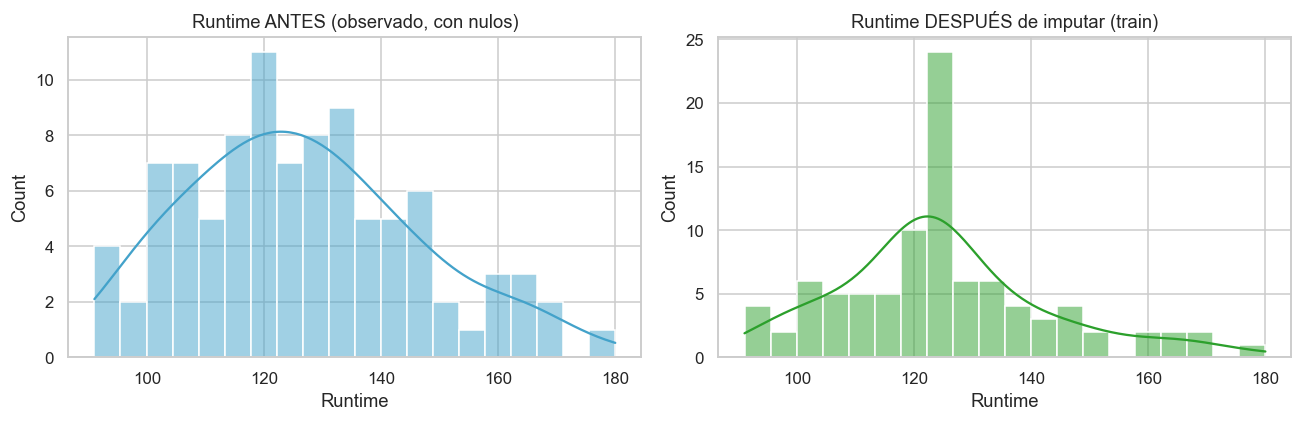

In [33]:
cols_imputar = ["Budget", "MetaCritic", "Runtime"]
medianas_train = train_df[cols_imputar].median()   # se aprende SOLO con train
print("Medianas aprendidas en train:"); print(medianas_train.round(1).to_string())

for c in cols_imputar:
    train_df[c] = train_df[c].fillna(medianas_train[c])
    test_df[c] = test_df[c].fillna(medianas_train[c])   # test usa la mediana de TRAIN

print("\nNulos tras imputar -> train:", int(train_df[cols_imputar].isna().sum().sum()),
      "| test:", int(test_df[cols_imputar].isna().sum().sum()))

# Chequeo visual: ¿la imputación distorsiona la distribución de Runtime?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Runtime"].dropna(), bins=20, kde=True, ax=axes[0], color="#43a2ca")
axes[0].set_title("Runtime ANTES (observado, con nulos)")
sns.histplot(train_df["Runtime"], bins=20, kde=True, ax=axes[1], color="#2ca02c")
axes[1].set_title("Runtime DESPUÉS de imputar (train)")
plt.tight_layout(); plt.show()

**Decisión por columna:**
- **`Budget` (2.6%, MCAR):** imputación por **mediana** (distribución sesgada; la media la arrastrarían los blockbusters).
- **`MetaCritic` (6%, MAR):** **mediana**; la cantidad es baja y no justifica técnicas avanzadas (Clase 5).
- **`Runtime` (18%, MAR/MCAR):** **mediana**; el histograma antes/después confirma que no distorsiona la forma. No se elimina la columna porque 18% << 70% y la variable es informativa.

### 4.3 Tratamiento de outliers (decisión por feature)
Antes de tratar hay que decidir si el outlier es un **error** o un **valor legítimo**. Errores → eliminar/imputar; valores extremos reales → **transformar** (log) o **acotar** (capping por percentil), para limitar su influencia sin borrarlos. Los límites se calculan en train.

Rating: capping a [7.50, 8.62] (percentiles 1-99 de train)


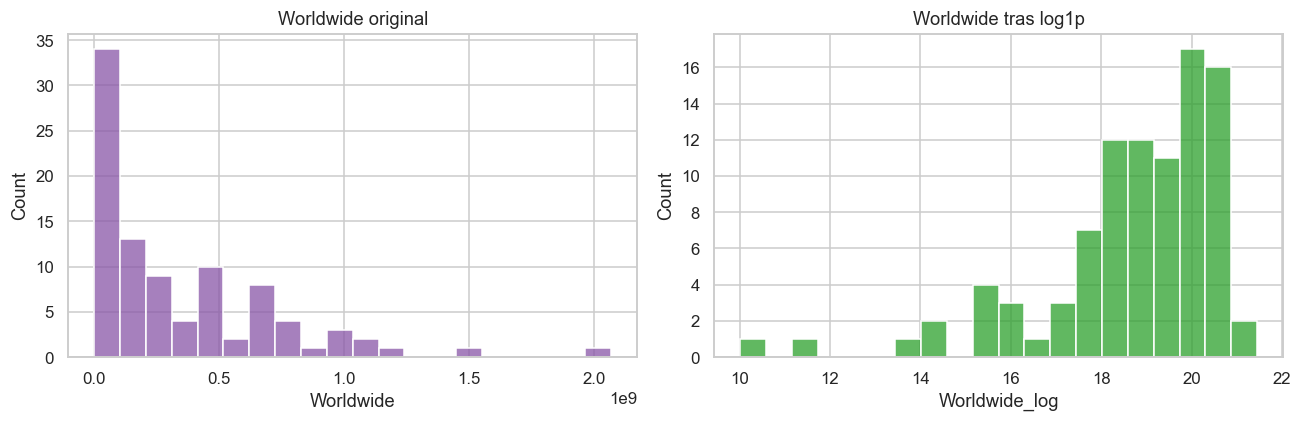

In [34]:
# Worldwide y TotalVotes: outliers = blockbusters REALES (no errores) -> log1p reduce su efecto sin borrar
for c in ["Worldwide", "TotalVotes"]:
    train_df[c + "_log"] = np.log1p(train_df[c])
    test_df[c + "_log"] = np.log1p(test_df[c])

# Rating: capping por percentil (límites 1-99 aprendidos en train)
lo, hi = train_df["Rating"].quantile([0.01, 0.99])
train_df["Rating_cap"] = train_df["Rating"].clip(lo, hi)
test_df["Rating_cap"] = test_df["Rating"].clip(lo, hi)   # se usan los límites de TRAIN
print(f"Rating: capping a [{lo:.2f}, {hi:.2f}] (percentiles 1-99 de train)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_df["Worldwide"], bins=20, ax=axes[0], color="#8856a7")
axes[0].set_title("Worldwide original")
sns.histplot(train_df["Worldwide_log"], bins=20, ax=axes[1], color="#2ca02c")
axes[1].set_title("Worldwide tras log1p")
plt.tight_layout(); plt.show()

**Decisión por feature:**
- **`Worldwide` / `TotalVotes`:** los outliers son blockbusters reales (patrón de la industria, no errores) → **transformación log1p** en vez de eliminarlos, para no perder información válida.
- **`Rating`:** 3 outliers por IQR, valores plausibles → **capping** suave (percentiles 1–99): limita su influencia conservando la fila.
- **`Budget` / `Runtime` / `MetaCritic`:** sin outliers relevantes (ver 3.4) → sin tratamiento.

### 4.4 Data cleaning de `genre` + One-Hot Encoding
`genre` tiene 41 registros con string vacío `""` (un faltante disfrazado): hay que resolverlo antes de codificar. Como una película puede tener **varios géneros** (relación 1-a-muchos), el One-Hot a nivel película es **multi-hot** (varias columnas en 1). La cardinalidad es baja (20 géneros) → One-Hot es apropiado.

In [35]:
# 1) DATA CLEANING: mostrar y resolver el string vacío
print("value_counts de genre ANTES (el '' aparece como categoría fantasma):")
print(genre["genre"].replace("", "(vacío)").value_counts().to_string())

genre_clean = genre.copy()
genre_clean["genre"] = genre_clean["genre"].str.strip()
genre_clean = genre_clean[genre_clean["genre"] != ""]     # quitamos los "" (sin género informado)
print(f"\nFilas antes: {len(genre)} | después de quitar vacíos: {len(genre_clean)} "
      f"| géneros únicos: {genre_clean['genre'].nunique()}")

# 2) ONE-HOT / multi-hot a nivel película (get_dummies + agregación por Movie_id)
multi_hot = (pd.get_dummies(genre_clean.set_index("Movie_id")["genre"])
             .groupby("Movie_id").max().astype(int))
multi_hot.columns = ["gen_" + c.replace(" ", "_") for c in multi_hot.columns]
print(f"\nMatriz multi-hot: {multi_hot.shape[0]} películas x {multi_hot.shape[1]} géneros")
display(multi_hot.head())

# 3) Variante con sklearn OneHotEncoder sobre el género PRINCIPAL (1 categoría por película)
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
gp = df_av[["genre_principal"]].fillna("Sin_dato")
ohe_df = pd.DataFrame(ohe.fit_transform(gp),
                      columns=ohe.get_feature_names_out(), index=df_av.index).astype(int)
print("\nOne-Hot (sklearn) sobre género principal:", ohe_df.shape)

# 4) Dataset de features con los géneros codificados, listo para modelar
df_modelo = df.merge(multi_hot, on="Movie_id", how="left")
df_modelo[multi_hot.columns] = df_modelo[multi_hot.columns].fillna(0).astype(int)
print("df_modelo con géneros codificados:", df_modelo.shape)

value_counts de genre ANTES (el '' aparece como categoría fantasma):
genre
Drama        77
Adventure    43
(vacío)      41
Action       33
Comedy       31
Biography    21
Sci-Fi       18
Thriller     14
Romance      13
Animation    13
Crime        11
Mystery       7
Fantasy       7
History       6
Sport         3
Family        3
Music         3
Western       2
War           2
Horror        2
Musical       1

Filas antes: 351 | después de quitar vacíos: 310 | géneros únicos: 20

Matriz multi-hot: 117 películas x 20 géneros


,gen_Action,gen_Adventure,gen_Animation,gen_Biography,gen_Comedy,gen_Crime,gen_Drama,gen_Family,gen_Fantasy,gen_History,gen_Horror,gen_Music,gen_Musical,gen_Mystery,gen_Romance,gen_Sci-Fi,gen_Sport,gen_Thriller,gen_War,gen_Western
Movie_id,,,,,,,,,,,,,,,,,,,,
10015,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
10023,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10099,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10454,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
10617,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0



One-Hot (sklearn) sobre género principal: (117, 18)
df_modelo con géneros codificados: (117, 74)


*Con el `""` resuelto, el género queda en columnas binarias `gen_*` (multi-hot: una película puede pertenecer a más de un género). `df_modelo` es la base para el modelado.*